# Party Movement, Crisis Response and Positions

This notebook covers:

1. **Party-level analysis**: what the party-year embeddings look like before any topic filtering.
2. **Analyze trajectories**: do the political events show up as movement
   in the embedding space? / Detect movement of parties triggered by crisis
3. **Party anchors**: where an axis can be
   anchored, where do the parties sit?
4. **Topic frequencies**: does an event change how much is said about its topics at all?

## 0. Setup and data

In [69]:
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from adjustText import adjust_text
from matplotlib.ticker import MaxNLocator
from aggregation_functions import aggregate_by_mp_year, aggregate_by_party_year

In [2]:
TOPICS     = "speech_topic_assignments.csv"                   # speech -> topic, from notebook 05
SPEECHES   = "jina_v3_contrastive_full.parquet"   # one row per speech, fine-tuned encoder
PARTY_YEAR = "party_year_embeddings_finetuned.parquet"   # party-year aggregates, from notebook 03

# one colour map for the whole notebook
PARTY_COLORS = {"CDU/CSU": "black", "SPD": "red", "Grüne": "green", "FDP": "gold",
                "LINKE": "purple", "AfD": "royalblue", "PDS": "darkorchid"}
party_colors = PARTY_COLORS   # parts 1 and 2 refer to it in lowercase

# figure styling, set once so every figure in the notebook looks the same
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

In [3]:
# data frame with speech to topic assignments
df_topics = pd.read_csv(TOPICS)
df_topics

,speaker_id,party,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name,date
0,11001434,SPD,604683,62,tanktourismus/markttransparenzstelle/benzinpreis,62,tanktourismus/markttransparenzstelle/benzinpreis,2000-01-19
1,11002754,CDU/CSU,604883,4,bafög-bericht/bologna-reform/studienfinanzierung,4,bafög-bericht/bologna-reform/studienfinanzierung,2000-01-20
2,11000431,SPD,604885,4,bafög-bericht/bologna-reform/studienfinanzierung,4,bafög-bericht/bologna-reform/studienfinanzierung,2000-01-20
3,11001180,FDP,604905,28,meerespolitik/wsv/pallas,28,meerespolitik/wsv/pallas,2000-01-20
4,11003216,CDU/CSU,605067,12,ptbs/wehrbeauftragter/penner,12,ptbs/wehrbeauftragter/penner,2000-01-21
...,...,...,...,...,...,...,...,...
82442,11004381,SPD,1060945,-1,unassigned,63,aufgabenplanung/deutsche-welle-gesetz/leistung...,2021-05-07
82443,11004854,CDU/CSU,1060947,-1,unassigned,17,stiftungsinitiative/stasi-unterlagen-gesetz/zw...,2021-05-07
82444,11004802,SPD,1060949,-1,unassigned,1,megahertz/polizeibeauftragten/netzneutralität,2021-05-07
82445,11004802,SPD,1060955,-1,unassigned,1,megahertz/polizeibeauftragten/netzneutralität,2021-05-07


In [4]:
# data frame with fine tuned embeddings
df_embeddings = pd.read_parquet(SPEECHES)
df_embeddings

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,year,year_month,n_tokens,used_in_finetune,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding
0,604683,Meine werten Kolleginnen und Kollegen! Liebe K...,11001434,Christoph Matschie,Christoph,Matschie,Member of Parliament,23,SPD,2000-01-19,2000,2000-01,1209,False,False,False,True,"[0.03820973, -0.11824905, 0.035603546, -0.0051..."
1,604883,Rot-grün und Bildungsministerin Bulmahn sind w...,11002754,thomas rachel,thomas,rachel,Member of Parliament,4,CDU/CSU,2000-01-20,2000,2000-01,988,False,False,False,True,"[0.043069527, -0.1234621, 0.08022803, 0.004297..."
2,604885,Meine sehr verehrten Damen und Herren! Ich ste...,11000431,peter eckardt,peter,eckardt,Member of Parliament,23,SPD,2000-01-20,2000,2000-01,1087,False,False,False,True,"[0.03223048, -0.10839531, 0.07345019, -0.00229..."
3,604905,Die aktuelle Lage der deutschen Werftindustrie...,11001180,jürgen koppelin,jürgen,koppelin,Member of Parliament,13,FDP,2000-01-20,2000,2000-01,1550,False,False,False,True,"[0.057155393, -0.12872227, 0.027934263, -0.038..."
4,605067,Verehrte Frau Wehrbeauftragte! Liebe Kolleginn...,11003216,anita schäfer,anita,schäfer,Member of Parliament,4,CDU/CSU,2000-01-21,2000,2000-01,1552,False,False,False,True,"[0.022645857, -0.14240317, 0.05878738, -0.0094..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82442,1060945,"Es ist schon ein besonderer Treppenwitz, dass ...",11004381,Martin Rabanus,Martin,Rabanus,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,991,False,False,False,True,"[0.106144175, -0.11403943, 0.059873722, 0.0198..."
82443,1060947,Verehrte Kolleginnen und Kollegen! Ich teile n...,11004854,Christoph Ploß,Christoph,Ploß,Member of Parliament,4,CDU/CSU,2021-05-07,2021,2021-05,943,False,False,False,True,"[0.068563156, -0.08838378, 0.11244867, -0.0153..."
82444,1060949,"Jetzt fühle mich fast an „Blockwart“ erinnert,...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,1153,False,False,False,True,"[0.10353798, -0.07043955, 0.06072252, 0.011076..."
82445,1060955,"Gut, ich beschränke mich auf einen Satz: Ich p...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,197,False,False,False,True,"[0.098100424, -0.12857388, 0.083329365, 0.0245..."


In [5]:
# merge embedding and topics data frame
df_embeddings_topics = df_embeddings.merge(
    df_topics.drop(columns=["party", "date"]),
    left_on="id", right_on="speech_id",
    how="inner"
)

df_embeddings_topics = df_embeddings_topics[df_embeddings_topics.party != 'Fraktionslos']
df_embeddings_topics

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
0,604683,Meine werten Kolleginnen und Kollegen! Liebe K...,11001434,Christoph Matschie,Christoph,Matschie,Member of Parliament,23,SPD,2000-01-19,...,False,False,True,"[0.03820973, -0.11824905, 0.035603546, -0.0051...",11001434,604683,62,tanktourismus/markttransparenzstelle/benzinpreis,62,tanktourismus/markttransparenzstelle/benzinpreis
1,604883,Rot-grün und Bildungsministerin Bulmahn sind w...,11002754,thomas rachel,thomas,rachel,Member of Parliament,4,CDU/CSU,2000-01-20,...,False,False,True,"[0.043069527, -0.1234621, 0.08022803, 0.004297...",11002754,604883,4,bafög-bericht/bologna-reform/studienfinanzierung,4,bafög-bericht/bologna-reform/studienfinanzierung
2,604885,Meine sehr verehrten Damen und Herren! Ich ste...,11000431,peter eckardt,peter,eckardt,Member of Parliament,23,SPD,2000-01-20,...,False,False,True,"[0.03223048, -0.10839531, 0.07345019, -0.00229...",11000431,604885,4,bafög-bericht/bologna-reform/studienfinanzierung,4,bafög-bericht/bologna-reform/studienfinanzierung
3,604905,Die aktuelle Lage der deutschen Werftindustrie...,11001180,jürgen koppelin,jürgen,koppelin,Member of Parliament,13,FDP,2000-01-20,...,False,False,True,"[0.057155393, -0.12872227, 0.027934263, -0.038...",11001180,604905,28,meerespolitik/wsv/pallas,28,meerespolitik/wsv/pallas
4,605067,Verehrte Frau Wehrbeauftragte! Liebe Kolleginn...,11003216,anita schäfer,anita,schäfer,Member of Parliament,4,CDU/CSU,2000-01-21,...,False,False,True,"[0.022645857, -0.14240317, 0.05878738, -0.0094...",11003216,605067,12,ptbs/wehrbeauftragter/penner,12,ptbs/wehrbeauftragter/penner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82442,1060945,"Es ist schon ein besonderer Treppenwitz, dass ...",11004381,Martin Rabanus,Martin,Rabanus,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.106144175, -0.11403943, 0.059873722, 0.0198...",11004381,1060945,-1,unassigned,63,aufgabenplanung/deutsche-welle-gesetz/leistung...
82443,1060947,Verehrte Kolleginnen und Kollegen! Ich teile n...,11004854,Christoph Ploß,Christoph,Ploß,Member of Parliament,4,CDU/CSU,2021-05-07,...,False,False,True,"[0.068563156, -0.08838378, 0.11244867, -0.0153...",11004854,1060947,-1,unassigned,17,stiftungsinitiative/stasi-unterlagen-gesetz/zw...
82444,1060949,"Jetzt fühle mich fast an „Blockwart“ erinnert,...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.10353798, -0.07043955, 0.06072252, 0.011076...",11004802,1060949,-1,unassigned,1,megahertz/polizeibeauftragten/netzneutralität
82445,1060955,"Gut, ich beschränke mich auf einen Satz: Ich p...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.098100424, -0.12857388, 0.083329365, 0.0245...",11004802,1060955,-1,unassigned,1,megahertz/polizeibeauftragten/netzneutralität


The anchored-position and frequency analysis in parts 3 and 4 works on the same merged table, only in a
slightly different shape: the placeholder speaker id `-1` is dropped and the embedding is kept as
a float32 array in the column `E`.

In [6]:
df = df_embeddings_topics[df_embeddings_topics.politicianId != -1].copy()
df["E"] = df.embedding.map(lambda v: np.asarray(v, dtype="float32"))

ALL_TOPICS = sorted(df.topic_emb_full_name.unique())
print(f"{len(df):,} speeches | {len(ALL_TOPICS)} topics | years {df.year.min()}-{df.year.max()}")
print(df.party.value_counts().to_string())

81,916 speeches | 72 topics | years 2000-2021
party
CDU/CSU    24032
SPD        18064
Grüne      14868
LINKE      10836
FDP        10381
AfD         2638
PDS         1097


## 1. Party-level analysis

Some graphs built from the party-year embeddings, before any topic filtering.

In [7]:
#import file
py = pd.read_parquet(PARTY_YEAR)

#PCA analysis
X = np.array(py["embedding"].tolist(), dtype="float32")
py[["x", "y"]] = PCA(n_components=2, random_state=42).fit_transform(X)

# drop the non-party outlier; drop very noisy low-count party-years
py = py[py["party"] != "Fraktionslos"].copy()
if "n_speeches" in py.columns:
    py = py[py["n_speeches"] >= 20].copy()

**Setup.** We reduce the 1024-dim party-year embeddings to 2D with PCA, then clean the data: drop *Fraktionslos* (not a real party — a noisy grab-bag of independents that otherwise dominates the plot) and drop any party-year built from fewer than 20 speeches (its average is too noisy to trust).

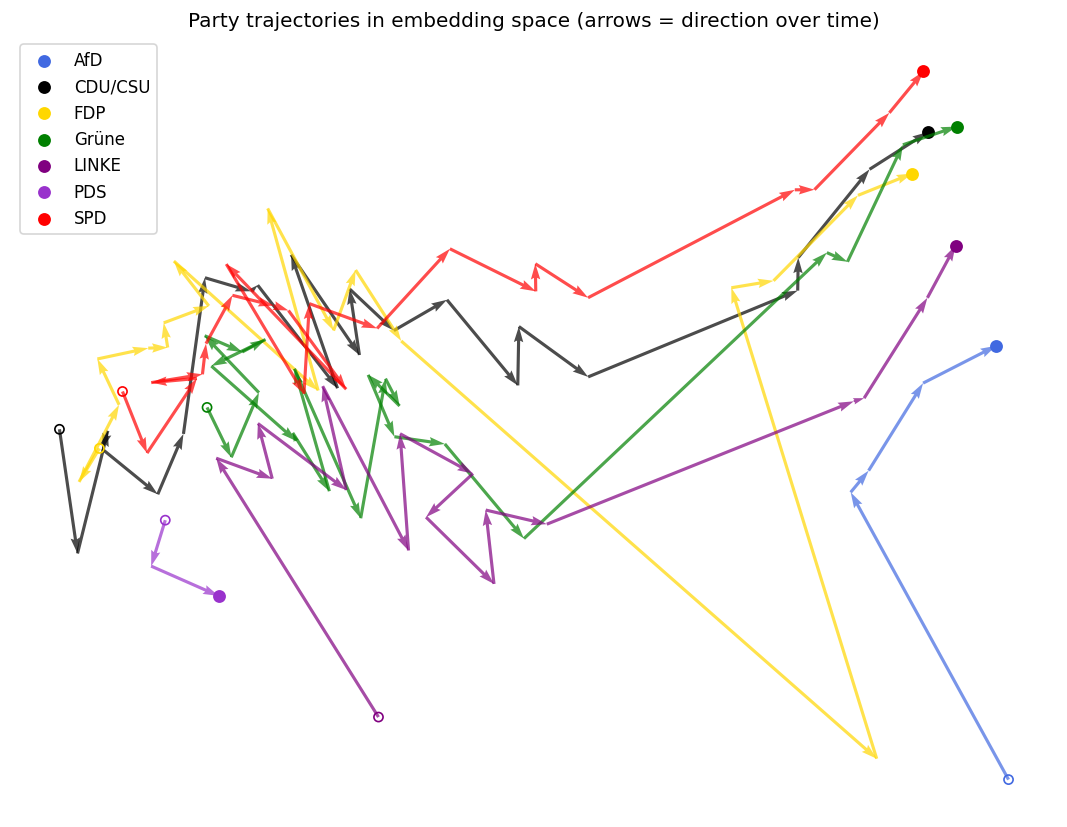

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
for party, g in py.sort_values("year").groupby("party"):
    c = party_colors.get(party, "grey")
    x, y = g["x"].values, g["y"].values
    ax.quiver(x[:-1], y[:-1], np.diff(x), np.diff(y),          # year -> year arrows
              angles="xy", scale_units="xy", scale=1, color=c, width=0.003, alpha=0.7)
    ax.scatter(x[0],  y[0],  facecolors="none", edgecolors=c, s=30)   # start (open)
    ax.scatter(x[-1], y[-1], color=c, s=45, label=party)             # end (filled)
ax.legend(); ax.axis("off")
ax.set_title("Party trajectories in embedding space (arrows = direction over time)")
plt.tight_layout(); plt.show()

**Party trajectories in embedding space.** Each arrow is one party's move from one year to the next; the open circle is its first year, the filled dot its last. Two things stand out. The paths are **tangled together** rather than running in separate lanes, and every party's **filled endpoint sits in the same corner** of the plot — they end up closer to each other than they started. Note these are PC1/PC2 (the *dominant* axes of variation), which mostly capture topic and era, so read this as *how much* a party's average speech shifted over time, not *in which political direction*. The two long, straight arrows (FDP, AfD) are not big moves either: they bridge years in which the party was absent from parliament.

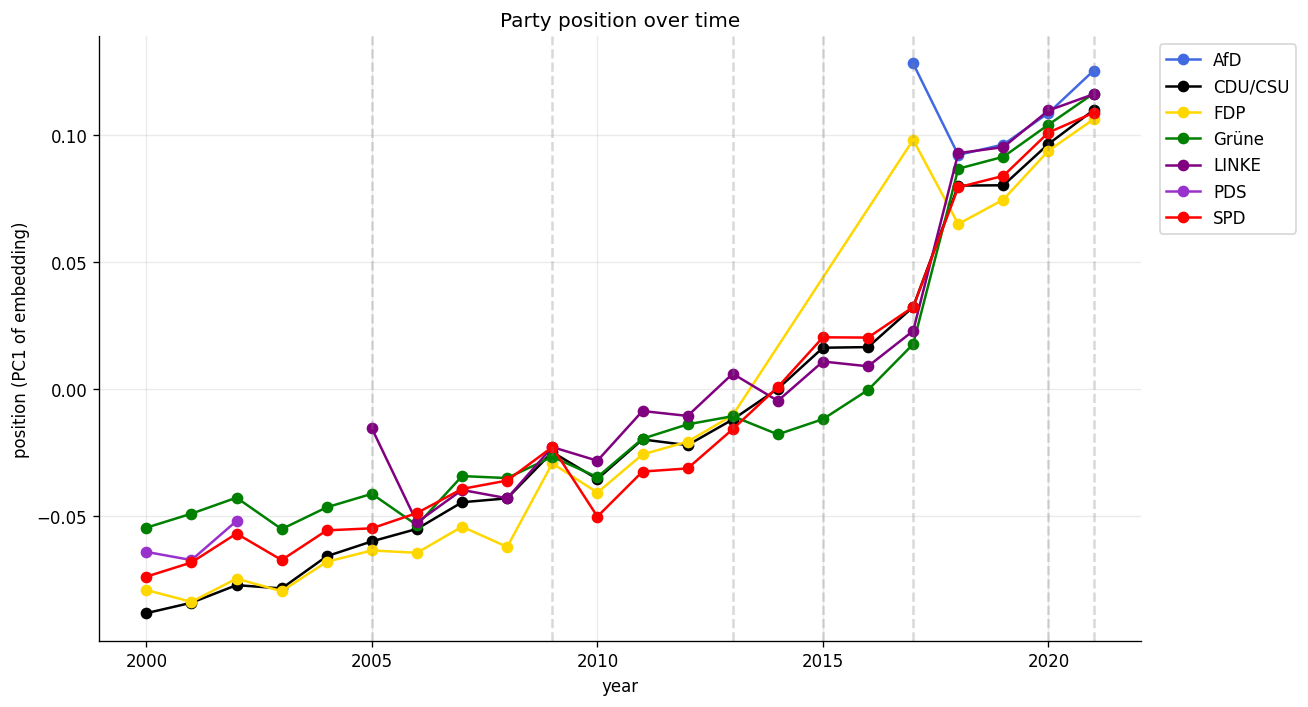

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
for party, g in py.sort_values("year").groupby("party"):
    ax.plot(g["year"], g["x"], marker="o", color=party_colors.get(party, "grey"), label=party)
# mark known events
for yr in [2005, 2009, 2013, 2015, 2017, 2020, 2021]:
    ax.axvline(yr, color="grey", ls="--", alpha=0.3)
ax.set_xlabel("year"); ax.set_ylabel("position (PC1 of embedding)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_title("Party position over time")
plt.tight_layout(); plt.show()

**Party position over time (PC1).** Each line is a party's position on the first principal component across the years; dashed lines mark elections/crises. The parties are **bunched** — in most years they sit within about 0.03 of each other — and the whole set **drifts upward together**, from roughly −0.08 in 2000 to about +0.11 in 2021, with the steepest part after 2013. A shared, parallel move like that is a **time / era effect**: PC1 is capturing how parliamentary language changed over the period, not left–right movement. The FDP's straight diagonal from 2013 to 2017 is a gap, not a jump — the party was out of parliament and has no party-years in between.

In [10]:
E = np.array(py["embedding"].tolist(), dtype="float32")      # (n_party_years, dim)

# left–right axis = (mean of right-anchor party-years) - (mean of left-anchor party-years)
left_anchor  = ["LINKE", "PDS"]        # far-left pole (present most of the period)
right_anchor = ["CDU/CSU"]             # mainstream-right pole; swap in "AfD" for a harder-right axis (2017+ only)

left_mean  = E[py["party"].isin(left_anchor).to_numpy()].mean(axis=0)
right_mean = E[py["party"].isin(right_anchor).to_numpy()].mean(axis=0)
axis = right_mean - left_mean
axis = axis / np.linalg.norm(axis)

py["lr"] = E @ axis                                          # higher = closer to the right pole
py["lr"] = (py["lr"] - py["lr"].mean()) / py["lr"].std()     # standardise for readability

# sanity check: parties should order roughly left -> right
print(py.groupby("party")["lr"].mean().sort_values())

events = [2005, 2009, 2013, 2015, 2017, 2020, 2021]

party
LINKE     -1.889472
AfD       -0.796145
PDS       -0.571592
Grüne     -0.055826
FDP        0.212468
SPD        0.752763
CDU/CSU    0.838501
Name: lr, dtype: float32


**Does the axis capture left–right? Only partly.** Ignore LINKE (−1.89) and CDU/CSU (+0.84) — they're the anchors, so they sit at the extremes by construction. Grüne (−0.06), FDP (+0.21) and PDS (−0.57) land sensibly, but **AfD (−0.80) and SPD (+0.75) are badly misplaced**: the AfD should be far right, the SPD centre-left, and here the SPD sits closer to the Union than any other party does. This is the classic *horseshoe* — AfD's oppositional rhetoric resembles LINKE's (both outsiders), and long-governing SPD resembles CDU/CSU (both establishment). So the embedding axis is really tracking **government/opposition and topic, not ideology**. Important caveat for any 'who moved left/right' reading — and a concrete example of where embeddings fall short of purpose-built scaling methods like Wordfish/Wordscores.

## 2. Analyze Trajectories

We test if the following political events appear as detectable movements in the embedding space
(embeddings aggregated by MP and year):

- 9/11 terror attacks
- Lehman Brothers collapse / global financial crisis
- Fukushima nuclear disaster
- Shift to migration scepticism in Germany (post-Cologne NYE)

To test, whether those events trigger movements of the embeddings, we first have to filter for
related topics. The four `TOPICS_*` lists defined below are the single topic–event assignment used
by the rest of the notebook — part 4 builds its `EVENTS` list from exactly these lists.

In [11]:
# List of all topics
print(df_embeddings_topics.topic_emb_full_name.unique())

['tanktourismus/markttransparenzstelle/benzinpreis'
 'bafög-bericht/bologna-reform/studienfinanzierung'
 'meerespolitik/wsv/pallas' 'ptbs/wehrbeauftragter/penner'
 'infrastrukturabgabe/straßenbaubericht/pällmann-kommission'
 'arzneimittelausgaben/rsa/psg'
 'stufenausbildung/verbundausbildung/altbewerberinnen'
 'tierhalter/imker/ställe'
 'oecd-musterabkommen/regelgrenze/mittelstandsentlastungsgesetz'
 'grexit/stabilisierungsmechanismus/syriza'
 'lohndiskriminierung/prostituierten/entgeltdiskriminierung'
 'anpassungsfonds/klimakonferenzen/ipcc-bericht'
 'mietenbericht/bestandsmieten/wohnungspolitiker'
 'lobbyistenregister/lobbyregister/parteiengesetzes'
 'erdverkabelung/netznutzungsentgelte/übertragungsnetzbetreibern'
 'waldbesitzer/waldstrategie/waldbesitzern'
 'stiftungsinitiative/stasi-unterlagen-gesetz/zwangsarbeiterinnen'
 'impfkampagne/astrazeneca/geimpfte'
 'messstationen/abschalteinrichtungen/hardwarenachrüstung'
 'dodik/uck/kosovos' 'belarussischen/lukaschenko/moldau'
 'föj/enga

### 9/11 terror attacks
Topic related to 9/11 terror attacks:
- 'isaf-mandats/isaf-mission/karzai' ("ISAF mandate / ISAF mission / Karzai")

The Afghanistan topic stands in for 9/11, since the corpus records the parliamentary consequences rather than the attack.

In [12]:
TOPICS_9_11 = [
    'isaf-mandats/isaf-mission/karzai'
]

df_9_11 = df_embeddings_topics[df_embeddings_topics.topic_emb_raw_name.isin(TOPICS_9_11)]

df_9_11

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
5222,625985,Die Freien Demokraten lehnen den Antrag der Bu...,11002944,Guido Westerwelle,Guido,Westerwelle,Member of Parliament,13,FDP,2001-06-01,...,False,False,True,"[0.0484316, -0.12063529, 0.05465001, -0.021245...",11002944,625985,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
5227,625999,Im Gegensatz zu Herrn Kollegen Merz möchte ich...,11000489,Gernot Erler,Gernot,Erler,Member of Parliament,23,SPD,2001-06-01,...,False,False,True,"[0.088499345, -0.117718354, 0.040650938, -0.02...",11000489,625999,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
5923,628942,"Nein, im Augenblick nicht. Ich bitte um Entsch...",11002278,Peter Struck,Peter,Struck,Member of Parliament,23,SPD,2001-10-11,...,False,False,True,"[0.03628148, -0.16026206, 0.06403307, -0.05424...",11002278,628942,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
6077,629572,"Vielen Dank, Herr Präsident! Es ist nicht das ...",11000996,Ulrich Irmer,Ulrich,Irmer,Member of Parliament,13,FDP,2001-10-18,...,False,False,True,"[0.03268463, -0.14294992, 0.088626824, -0.0324...",11000996,629572,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
6080,629582,Verehrte Kolleginnen und Kollegen! Wer in eine...,11000181,Rudolf Bindig,Rudolf,Bindig,Member of Parliament,23,SPD,2001-10-18,...,False,False,True,"[0.05239607, -0.16260496, 0.09905398, -0.02258...",11000181,629582,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82424,1060876,Vor allem: Lieber Herr Kollege Lucassen! Sie s...,11004656,Philipp Amthor,Philipp,Amthor,Member of Parliament,4,CDU/CSU,2021-05-07,...,False,False,True,"[0.074197166, -0.12993331, 0.08358965, -0.0191...",11004656,1060876,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
82425,1060880,"Ich bin ganz irritiert, Herr Amthor, dass wir ...",11004906,Marie-Agnes Strack-Zimmermann,Marie-Agnes,Strack-Zimmermann,Member of Parliament,13,FDP,2021-05-07,...,False,False,True,"[0.039036125, -0.13014202, 0.089285806, -0.015...",11004906,1060880,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
82426,1060884,Die Bundeswehr befindet sich derzeit in zehn m...,11004361,Alexander S. Neu,Alexander S.,Neu,Member of Parliament,6,LINKE,2021-05-07,...,False,False,True,"[0.06730394, -0.1388349, 0.06838469, -0.022937...",11004361,1060884,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai
82428,1060890,Sehr verehrte Frau Präsidentin! Meine verehrte...,11004256,Karl-Heinz Brunner,Karl-Heinz,Brunner,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.075418845, -0.1311105, 0.0935403, 0.0201109...",11004256,1060890,24,isaf-mandats/isaf-mission/karzai,24,isaf-mandats/isaf-mission/karzai


### Lehman Brothers collapse / global financial crisis
Topic related to Lehman Brothers collapse / global financial crisis:
- 'pfandbrief/vermögensanlagen/kapitalanlagegesetzbuch' ("covered bond (Pfandbrief) / asset investments / capital investment code")

In [13]:
TOPICS_FINANCE = [
    'pfandbrief/vermögensanlagen/kapitalanlagegesetzbuch'
]

df_financial_crisis = df_embeddings_topics[df_embeddings_topics.topic_emb_full_name.isin(TOPICS_FINANCE)]
df_financial_crisis

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
545,606528,Das neue Insolvenzrecht ist bekanntlich vor gu...,11003159,evelyn kenzler,evelyn,kenzler,Member of Parliament,22,PDS,2000-02-18,...,False,False,True,"[0.07557646, -0.05016817, 0.01691161, 0.001943...",11003159,606528,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
704,607153,"Ich hatte gestern Abend das Vergnügen, mit dem...",11002093,dietmar schütz,dietmar,schütz,Member of Parliament,23,SPD,2000-02-25,...,False,False,True,"[0.09834212, -0.12836099, 0.043255042, -0.0057...",11002093,607153,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
863,608200,Meine sehr verehrten Damen und Herren! Die ang...,11001319,Klaus Lennartz,Klaus,Lennartz,Member of Parliament,23,SPD,2000-03-23,...,False,False,True,"[0.09510677, -0.0747031, 0.016247753, -0.03928...",11001319,608200,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
908,608220,Verehrte Kolleginnen und Kollegen! Der Vorgang...,11002728,Christa Luft,Christa,Luft,Member of Parliament,22,PDS,2000-03-23,...,False,False,True,"[0.10418292, -0.075572535, -0.010280163, -0.02...",11002728,608220,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
919,608202,"das mache ich -, die nicht nur vom Schreibtisc...",11001319,Klaus Lennartz,Klaus,Lennartz,Member of Parliament,23,SPD,2000-03-23,...,False,False,True,"[0.11537251, -0.082092434, -0.021792363, -0.03...",11001319,608202,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81646,1058424,Man muss sagen: Das ist ja eine einigermaßen h...,11003050,Lothar Binding,Lothar,Binding,Member of Parliament,23,SPD,2021-04-15,...,False,False,True,"[0.087703556, -0.11116112, 0.000881334, -0.005...",11003050,1058424,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
82011,1059527,Der im Gesetz gewählte Ansatz einer Standort- ...,11004693,Jörg Cezanne,Jörg,Cezanne,Member of Parliament,6,LINKE,2021-04-22,...,False,False,True,"[0.12070217, -0.0970909, -0.028573353, -0.0243...",11004693,1059527,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
82344,1060614,Vielen Dank. – Herr Präsident! Liebe Kolleginn...,11003050,Lothar Binding,Lothar,Binding,Member of Parliament,23,SPD,2021-05-06,...,False,False,True,"[0.11310496, -0.099049255, 0.01959681, 0.00182...",11003050,1060614,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...
82345,1060618,Mit dem Schwarmfinanzierungs-Begleitgesetz bri...,11004684,Carsten Brodesser,Carsten,Brodesser,Member of Parliament,4,CDU/CSU,2021-05-06,...,False,False,True,"[0.043757625, -0.052062307, -0.008626161, 0.01...",11004684,1060618,-1,unassigned,14,pfandbrief/vermögensanlagen/kapitalanlagegeset...


### Fukushima nuclear disaster
Topics related to 'Fukushima nuclear disaster':
- 'schwarzelühr-sutter/reaktorsicherheit/reaktoren' ("Schwarzelühr-Sutter (a surname) / reactor safety / reactors")
- 'entsorgungskonzept/salzstocks/sellafield' ("disposal concept / salt domes / Sellafield")

In [14]:
TOPICS_FUKUSHIMA = [
    'schwarzelühr-sutter/reaktorsicherheit/reaktoren',
    'entsorgungskonzept/salzstocks/sellafield'
]

df_fukushima = df_embeddings_topics[df_embeddings_topics.topic_emb_full_name.isin(TOPICS_FUKUSHIMA)]
df_fukushima

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
43,616578,"Man kann es drehen, wie man will: In den Augen...",11002678,Walter Hirche,Walter,Hirche,Member of Parliament,13,FDP,2000-11-15,...,False,False,True,"[0.08811338, -0.12637773, 0.05681287, 3.15967e...",11002678,616578,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield
45,616776,"Wir haben von der früheren DDR-Regierung, von ...",11001353,Klaus W Lippold,Klaus W,Lippold,Member of Parliament,4,CDU/CSU,2000-11-16,...,False,False,True,"[0.075086564, -0.12212144, 0.023355529, -0.031...",11001353,616776,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield
171,604915,Der schwerste Reaktorunfall in der westlichen ...,11001293,paul laufs,paul,laufs,Member of Parliament,4,CDU/CSU,2000-01-20,...,False,False,True,"[0.13581339, -0.116223566, 0.047298197, 0.0051...",11001293,604915,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield
172,604917,Wir behandeln heute in erster Lesung einen kur...,11001234,horst kubatschka,horst,kubatschka,Member of Parliament,23,SPD,2000-01-20,...,False,False,True,"[0.093415335, -0.059045605, 0.0424054, 0.00773...",11001234,604917,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield
173,604919,Meine Kolleginnen und Kollegen! Ich möchte zun...,11000952,birgit homburger,birgit,homburger,Member of Parliament,13,FDP,2000-01-20,...,False,False,True,"[0.09269338, -0.10441279, 0.03717757, -0.02063...",11000952,604919,-1,unassigned,29,entsorgungskonzept/salzstocks/sellafield
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81530,1058084,Meine sehr verehrten Damen und Herren! Als ich...,11004732,Timon Gremmels,Timon,Gremmels,Member of Parliament,23,SPD,2021-04-13,...,False,False,True,"[0.073475845, -0.068871774, 0.02380795, -0.022...",11004732,1058084,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield
81531,1058086,Es geht heute um die Energieversorgung in Deut...,11004120,Martin Neumann,Martin,Neumann,Member of Parliament,13,FDP,2021-04-13,...,False,False,True,"[0.098377086, -0.09993328, 0.05341199, -0.0281...",11004120,1058086,-1,unassigned,29,entsorgungskonzept/salzstocks/sellafield
81534,1058092,Ich will noch mal deutlich machen: Natürlich b...,11004120,Martin Neumann,Martin,Neumann,Member of Parliament,13,FDP,2021-04-13,...,False,False,True,"[0.10527904, -0.14324795, 0.044987656, -0.0053...",11004120,1058092,-1,unassigned,29,entsorgungskonzept/salzstocks/sellafield
81535,1058102,Im April 1986 war ich sieben Jahre alt. Ich wa...,11004672,Lorenz Gösta Beutin,Lorenz Gösta,Beutin,Member of Parliament,6,LINKE,2021-04-13,...,False,False,True,"[0.10541044, -0.15859087, 0.027539007, -0.0110...",11004672,1058102,29,entsorgungskonzept/salzstocks/sellafield,29,entsorgungskonzept/salzstocks/sellafield


### Shift to migration scepticism in Germany (post-Cologne NYE)

Topics related to the shift to migration scepticism in Germany (post-Cologne NYE):
- 'mehrstaatigkeit/dublin-ii-verordnung/optionspflicht' ("multiple nationality / Dublin II regulation / option requirement")

In [15]:
TOPICS_MIGRATION = [
    'mehrstaatigkeit/dublin-ii-verordnung/optionspflicht'
]

df_migration = df_embeddings_topics[df_embeddings_topics.topic_emb_raw_name.isin(TOPICS_MIGRATION)]

df_migration

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
147,604841,Der Kollege Tauss ist ja am Schluss derart in ...,11002678,walter hirche,walter,hirche,Member of Parliament,13,FDP,2000-01-20,...,False,False,True,"[0.070309855, -0.12695086, 0.07869413, 0.03328...",11002678,604841,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
390,606019,"Herr Minister, zunächst eine ganz kurze Vorbem...",11002770,Hartmut Schauerte,Hartmut,Schauerte,Member of Parliament,4,CDU/CSU,2000-02-16,...,False,False,True,"[0.041170742, -0.16246921, 0.07832348, 0.01728...",11002770,606019,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
779,607535,Aufgrund einer Initiative der CDU/CSU-Bundesta...,11002632,Wolfgang Bosbach,Wolfgang,Bosbach,Member of Parliament,4,CDU/CSU,2000-03-16,...,False,False,True,"[0.04356148, -0.12328048, 0.074834384, 0.02726...",11002632,607535,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
780,607537,Auch wenn dieses Angebot noch so freundlich ge...,11003249,Rüdiger Veit,Rüdiger,Veit,Member of Parliament,23,SPD,2000-03-16,...,False,False,True,"[0.04441368, -0.111941434, 0.08770614, 0.02239...",11003249,607537,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
781,607550,"Innenminister Schily hat gesagt, das Problem l...",11003247,Hans-Peter Uhl,Hans-Peter,Uhl,Member of Parliament,4,CDU/CSU,2000-03-16,...,False,False,True,"[0.01720537, -0.1693599, 0.13183902, 0.0236222...",11003247,607550,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81314,1057395,"Nein, danke. – Vor allem stellt sich mir die F...",11004652,Grigorios Aggelidis,Grigorios,Aggelidis,Member of Parliament,13,FDP,2021-03-25,...,False,False,True,"[0.059380356, -0.16323292, 0.0784931, -0.00555...",11004652,1057395,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
81710,1058603,Werte Kollegen! Ich bin ein optimistischer Men...,11004936,Christian Wirth,Christian,Wirth,Member of Parliament,0,AfD,2021-04-15,...,False,False,True,"[0.044358496, -0.15327023, 0.09969344, 0.02846...",11004936,1058603,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
81711,1058607,"Ich wiederhole, was Herr Dr. Wirth gesagt hat ...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-04-15,...,False,False,True,"[0.0077297105, -0.12962928, 0.11264864, 0.0146...",11004802,1058607,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...
81795,1058855,Die Angemessenheit ist immer sichtbedingt. Der...,11004439,Albert H. Weiler,Albert H.,Weiler,Member of Parliament,4,CDU/CSU,2021-04-16,...,False,False,True,"[-0.0064771743, -0.13830407, 0.05604233, 0.000...",11004439,1058855,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...,5,mehrstaatigkeit/dublin-ii-verordnung/optionspf...


### Plot trajectories
We plot the party trajectories reduced to two dimensions via PCA in a single plot, restricted to the years around the event we want to detect, to keep the plot readable.

In [53]:
def plot_trajectory(df, year, timespan, topic, crisis):

    # restrict to the years around the event (to make plots more readable)
    df = df[(df["year"] >= timespan[0]) & (df["year"] <= timespan[1])]

    # aggregate the filtered embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to two dimensions
    pca_traj = PCA(n_components=2)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "dim1": pcs_traj[:, 0],
        "dim2": pcs_traj[:, 1],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    fig, ax = plt.subplots()
    texts = []

    # plot trajectories
    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]

        # skip parties with no speech in the event year itself
        if year not in subset["year"].values:
            continue

        # line stays faint, markers on top stay fully opaque
        ax.plot(subset["dim1"], subset["dim2"], color=color, label=party, alpha=0.3)
        ax.scatter(subset["dim1"], subset["dim2"], color=color, s=15, zorder=4)

        if len(subset) >= 2:
            ax.annotate('', xy=(subset["dim1"].iloc[1], subset["dim2"].iloc[1]),
                            xytext=(subset["dim1"].iloc[0], subset["dim2"].iloc[0]),
                            arrowprops=dict(arrowstyle='->', color=color, lw=2, alpha=0.3))

        # highlight the event year
        year_row = subset[subset["year"] == year]
        ax.scatter(year_row["dim1"], year_row["dim2"], color=color,
                   s=80, edgecolors="black", zorder=5)

        # collect the label for the event year, adjusted afterwards to avoid overlap
        texts.append(ax.text(year_row["dim1"].iloc[0], year_row["dim2"].iloc[0],
                             f"{year} ({crisis})", fontsize=8, color=color))

    adjust_text(texts, ax=ax)

    ax.legend(loc="lower right")
    ax.axis("off")
    ax.set_title(f"Trajectories of Party-Year Embeddings ({topic})")
    plt.tight_layout()
    plt.show()

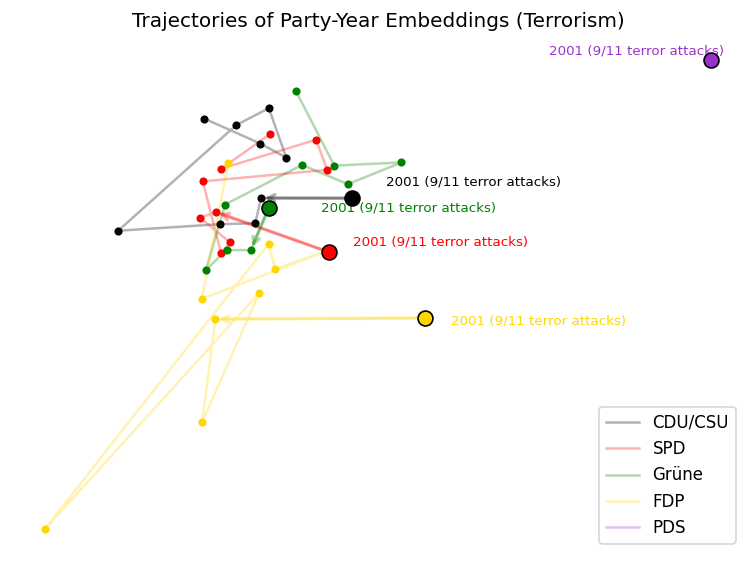

In [54]:
plot_trajectory(df_9_11, 2001, [2000, 2010], 'Terrorism', '9/11 terror attacks')

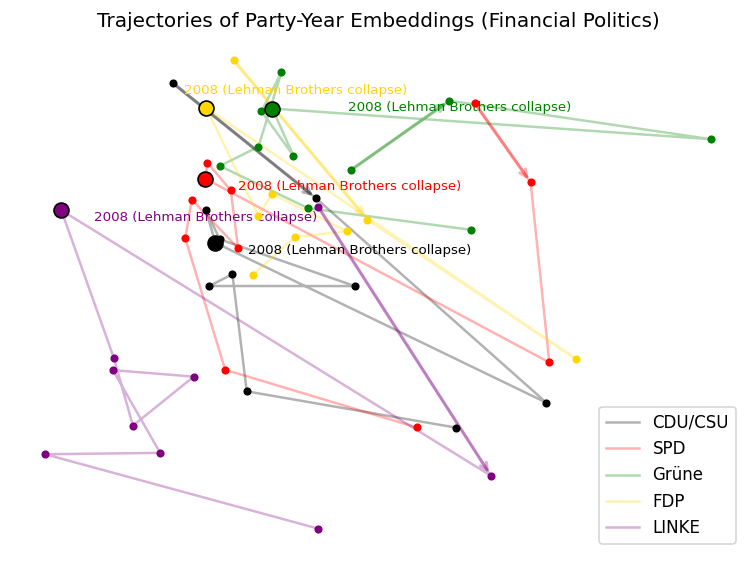

In [55]:
plot_trajectory(df_financial_crisis, 2008, [2005, 2015], 'Financial Politics', 'Lehman Brothers collapse')

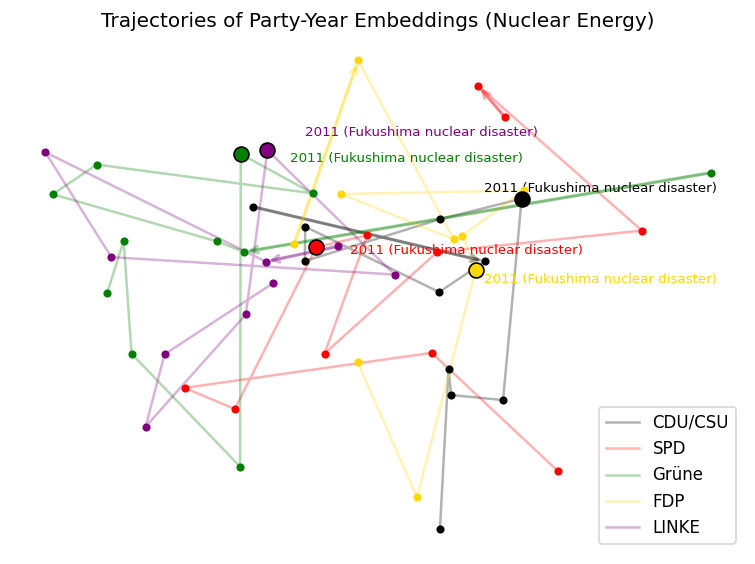

In [56]:
plot_trajectory(df_fukushima, 2011, [2005, 2015], 'Nuclear Energy', 'Fukushima nuclear disaster')

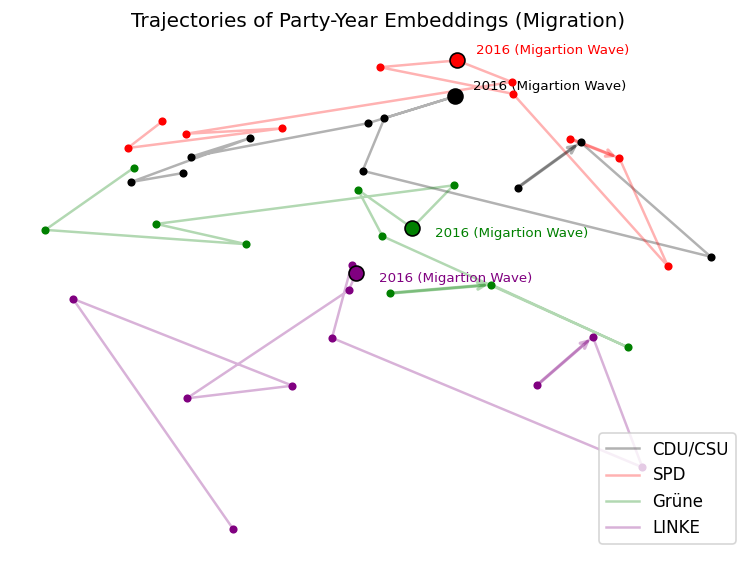

In [57]:
plot_trajectory(df_migration, 2016, [2011, 2021], 'Migration', 'Migartion Wave')

**Reading the four trajectory plots.** Each panel runs its own PCA on the party-year embeddings of that
topic alone, so the axes are not comparable between panels and carry no political meaning of their own;
only the shape of a path within one panel says anything. The function also draws an arrow for the first
step; the year where the crisis happend is indicated by a lable.

Since the trajectories in a single combined plot are hard to read, we split this up and create one 2D PCA trajectory plot per party instead, covering the party's full time range (not restricted to the event window).

In [202]:
def plot_trajectory_per_party(df, year, topic, crisis, timespan):

    # restrict to the years around the event, same as plot_trajectory,
    # so the PCA is fit on the same data and trajectories are comparable
    df = df[(df["year"] >= timespan[0]) & (df["year"] <= timespan[1])]

    # aggregate the filtered embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to two dimensions (fit once, across all parties)
    pca_traj = PCA(n_components=2)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "dim1": pcs_traj[:, 0],
        "dim2": pcs_traj[:, 1],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # one plot per party
    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]

        # skip parties with no speech in the event year itself
        if year not in subset["year"].values:
            continue

        fig, ax = plt.subplots(figsize=(6, 5))

        # line between points stays faint, markers on top stay fully opaque
        ax.plot(subset["dim1"], subset["dim2"], color=color, alpha=0.3)
        ax.scatter(subset["dim1"], subset["dim2"], color=color, s=15, zorder=4)

        # arrows between all consecutive points, to show the full trajectory direction
        for i in range(len(subset) - 1):
            ax.annotate('', xy=(subset["dim1"].iloc[i+1], subset["dim2"].iloc[i+1]),
                            xytext=(subset["dim1"].iloc[i], subset["dim2"].iloc[i]),
                            arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.3))

        # collect labels for adjustText instead of placing them with a fixed offset
        texts = []
        for i in range(len(subset)):
            yr = subset["year"].iloc[i]
            label = f"{yr} ({crisis})" if yr == year else str(yr)
            texts.append(ax.text(subset["dim1"].iloc[i], subset["dim2"].iloc[i],
                                 label, fontsize=8, color=color))

        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color=color, lw=0.5))

        # highlight the event year
        year_row = subset[subset["year"] == year]
        ax.scatter(year_row["dim1"], year_row["dim2"], color=color,
                   s=80, edgecolors="black", zorder=5)

        ax.axis("off")
        ax.set_title(f"{party} — Trajectory of Year Embeddings ({topic})")
        plt.tight_layout()
        plt.show()

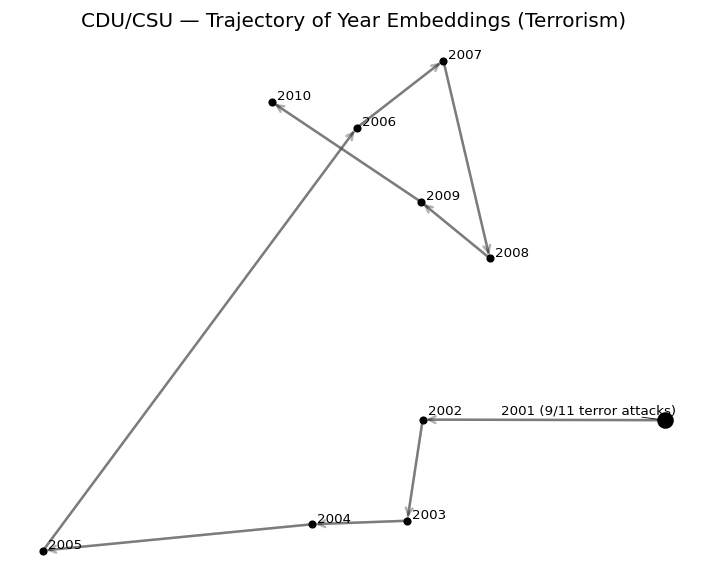

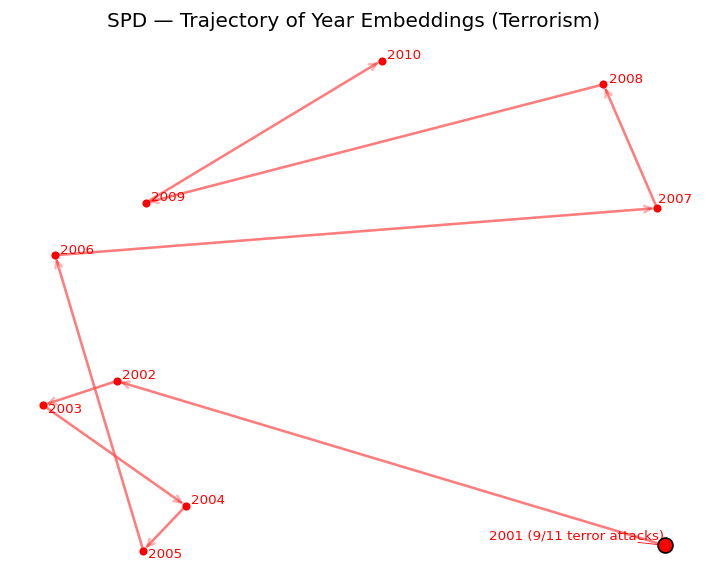

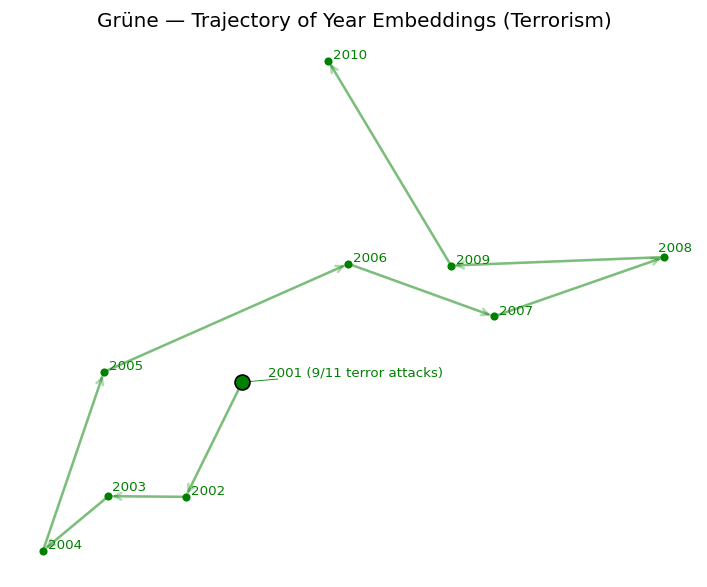

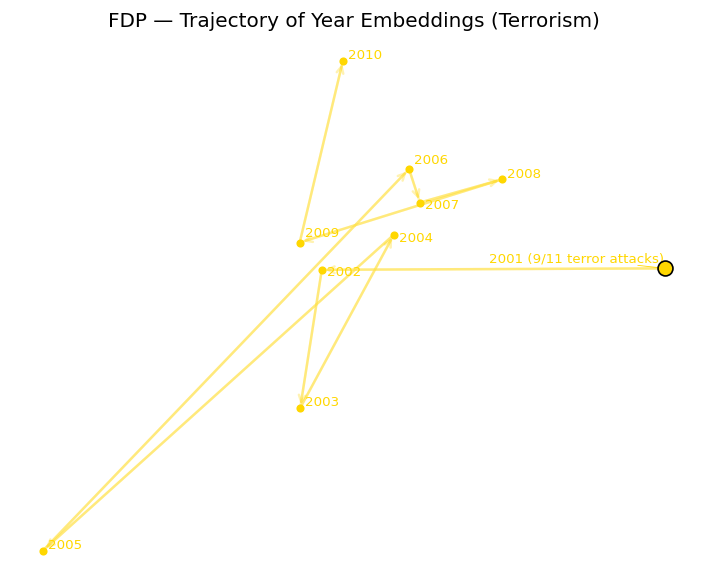

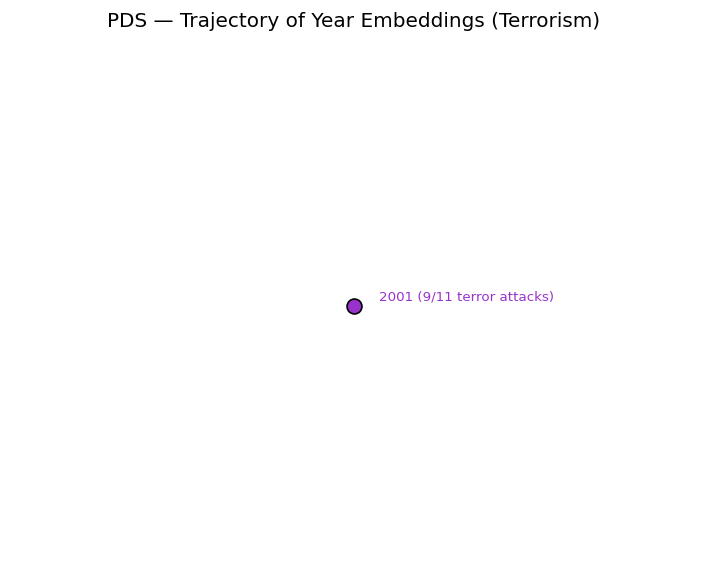

In [208]:
plot_trajectory_per_party(df_9_11, 2001, 'Terrorism', '9/11 terror attacks', [2000, 2010])

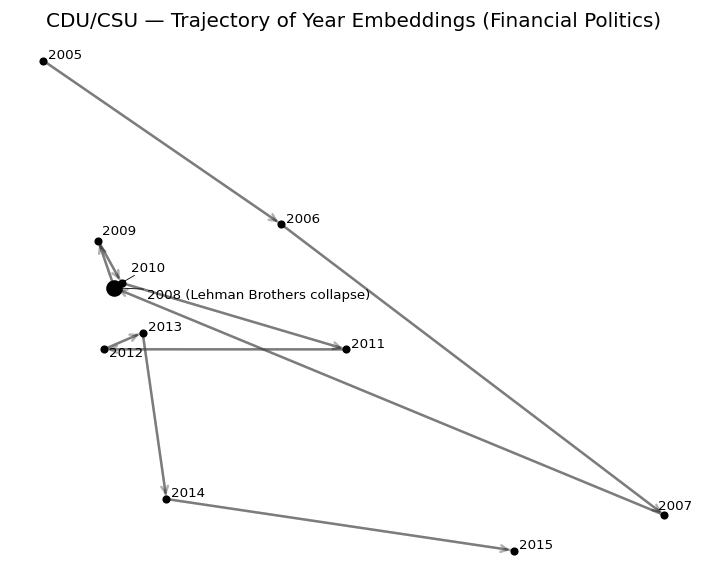

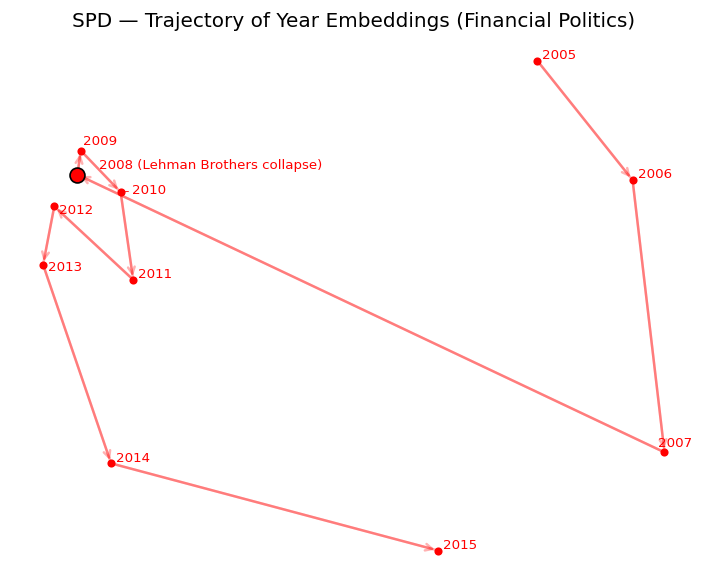

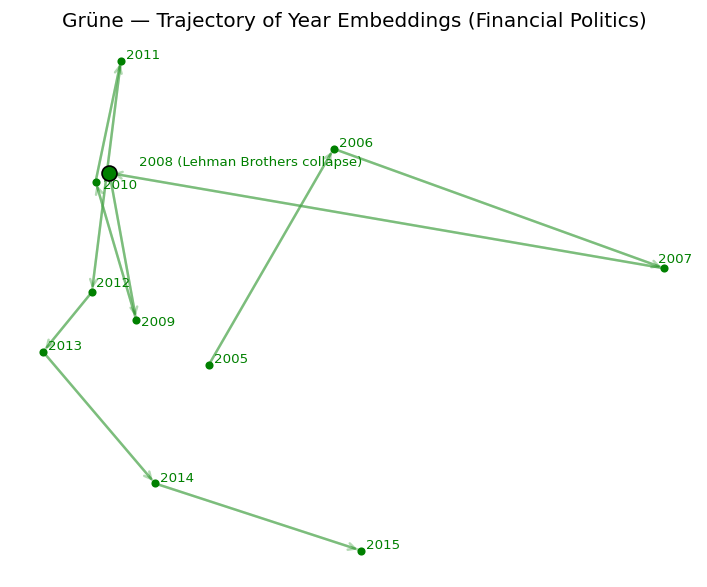

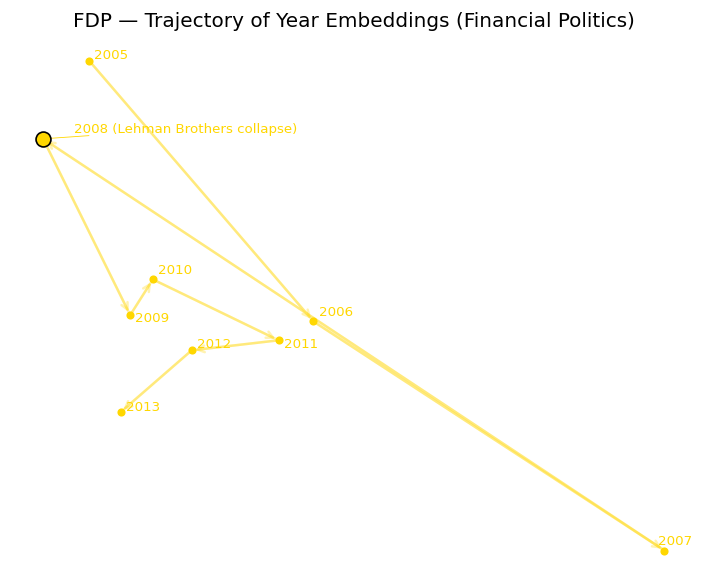

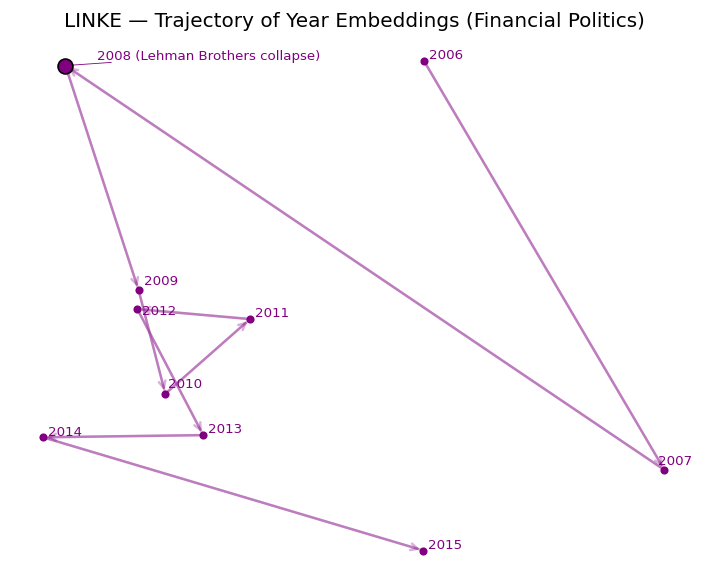

In [207]:
plot_trajectory_per_party(df_financial_crisis, 2008, 'Financial Politics', 'Lehman Brothers collapse', [2005, 2015])

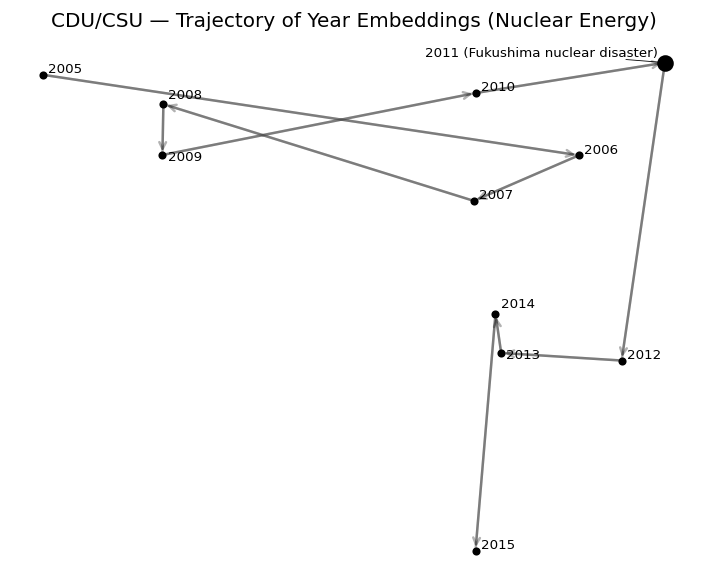

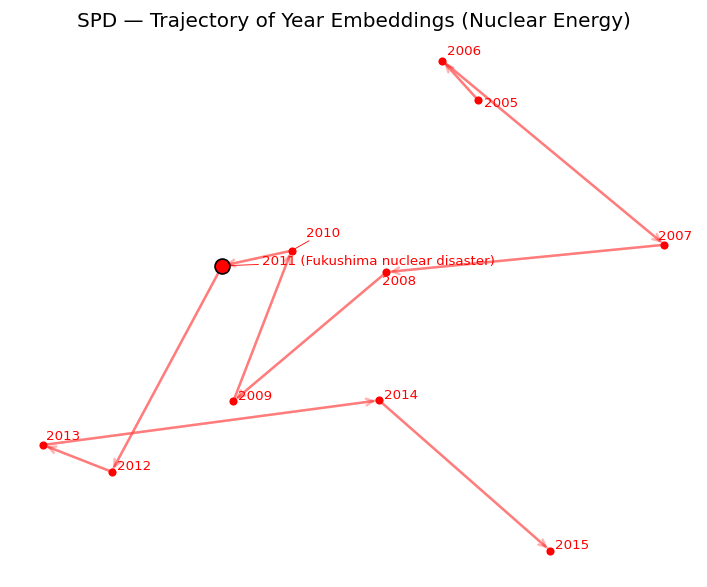

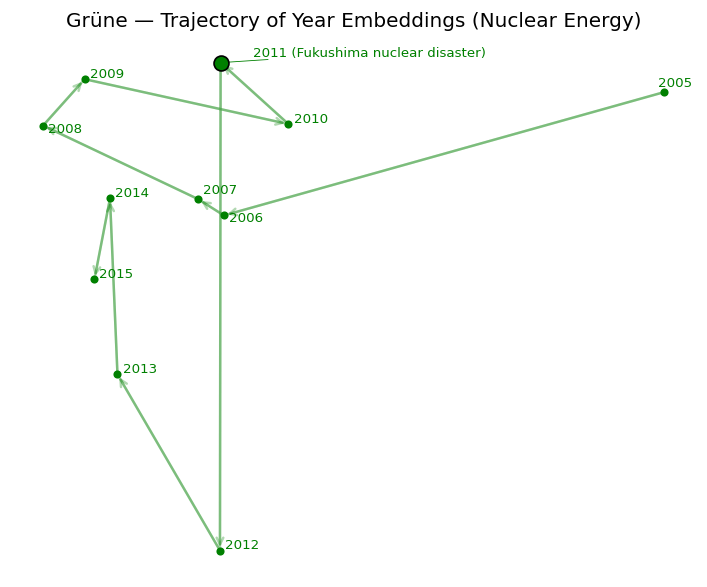

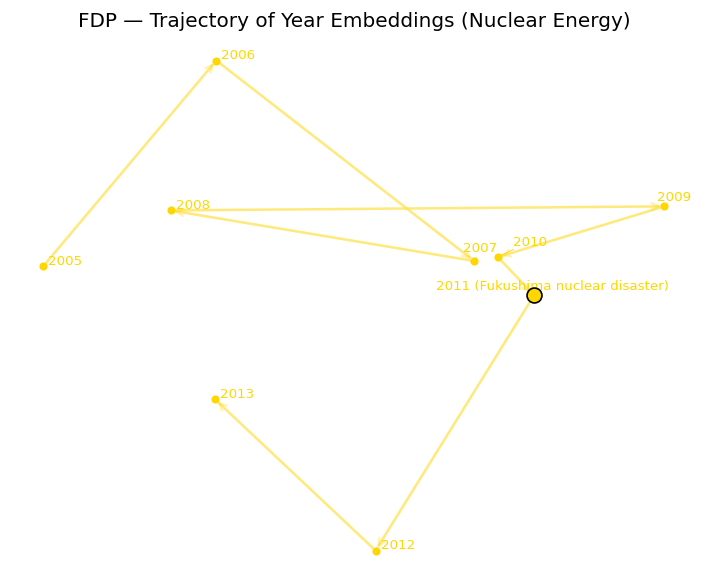

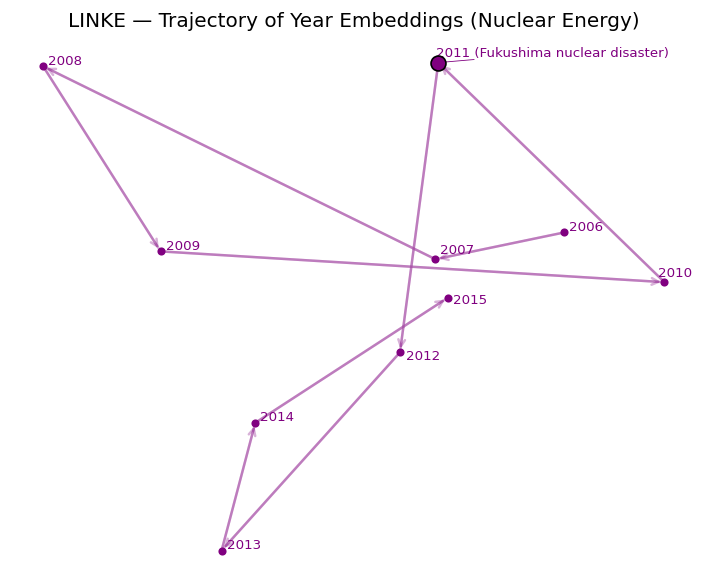

In [206]:
plot_trajectory_per_party(df_fukushima, 2011, 'Nuclear Energy', 'Fukushima nuclear disaster', [2005, 2015])

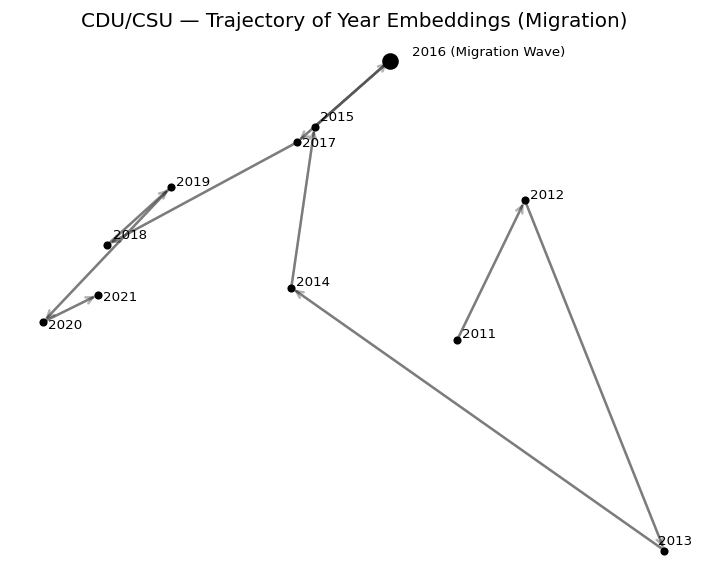

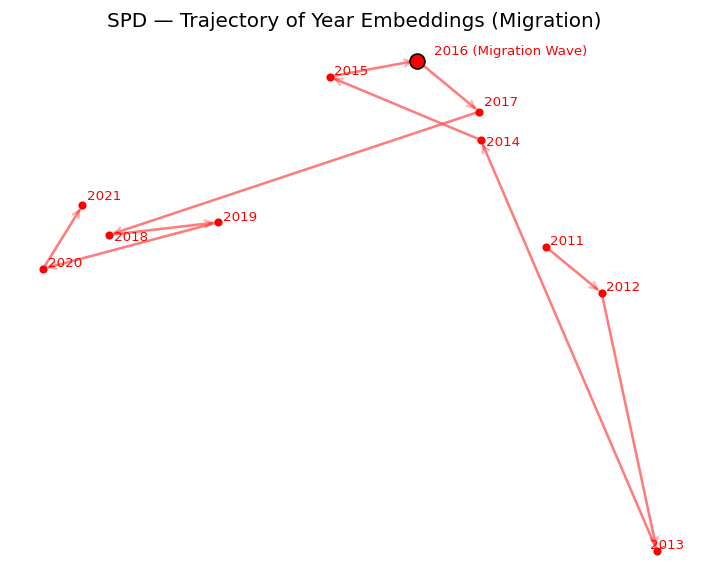

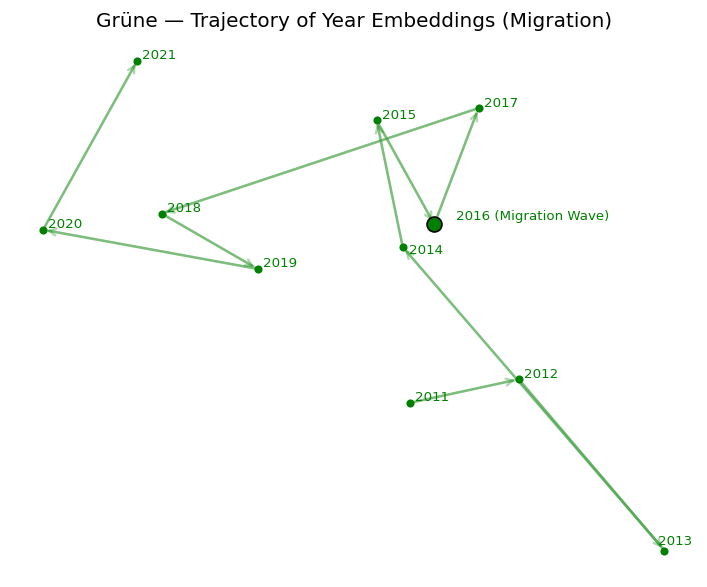

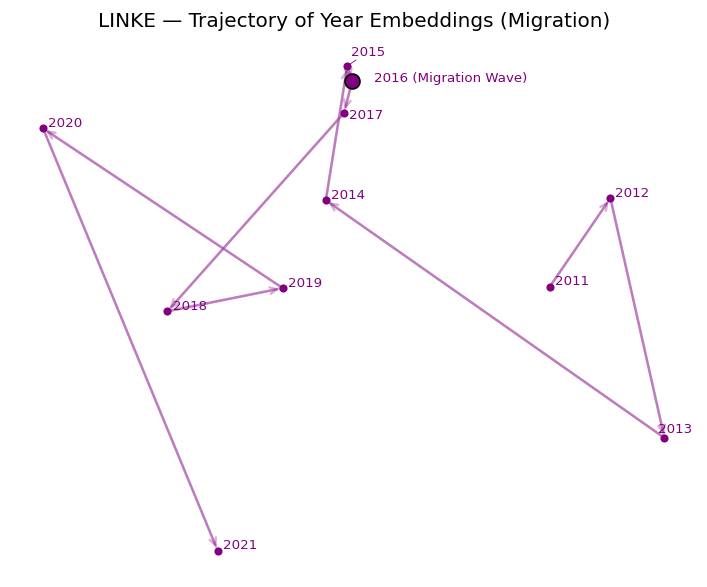

In [205]:
plot_trajectory_per_party(df_migration, 2016, 'Migration', 'Migration Wave', [2011, 2021])

**Per-party panels.** The same embeddings, one panel per party, with every year labelled and the event
year drawn as a large dot. Spreading the parties out makes individual years readable, but the event dot
lands in the middle of the cloud in every panel — the Grüne's 2011 on the nuclear topic, for instance,
sits right between 2009 and 2010.

What the panels do show is where the noise lives: the long excursions are almost always the thin years
at the end of each series (2018–2021), where a party contributes only a handful of speeches to the topic
and its yearly mean is decided by whichever debates happened to fall in that year.

To make the time axis easier to interpret, we reduce the embedding space to a single dimension (PC1) instead of two, and plot each party's PC1 value over the years directly, with the event year marked by a vertical line.

In [72]:
def plot_trajectory_1d(df, year, topic, crisis):

    # aggregate the embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to one dimension
    pca_traj = PCA(n_components=1)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "pc1": pcs_traj[:, 0],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    fig, ax = plt.subplots()

    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]

        # skip parties with no speech in the event year itself
        if year not in subset["year"].values:
            continue

        ax.plot(subset["year"], subset["pc1"], color=color, label=party, marker='o', markersize=3)

    # mark the event year and label it
    ax.axvline(year, color="grey", linestyle="--", linewidth=1)
    ax.annotate(crisis, (year, ax.get_ylim()[1]), xytext=(3, -10),
                textcoords="offset points", fontsize=8, color="0.2")

    # force integer year ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xlabel("Year")
    ax.set_ylabel("PC1")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(f"PC1 of Party-Year Embeddings over Time ({topic})")
    plt.tight_layout()
    plt.show()

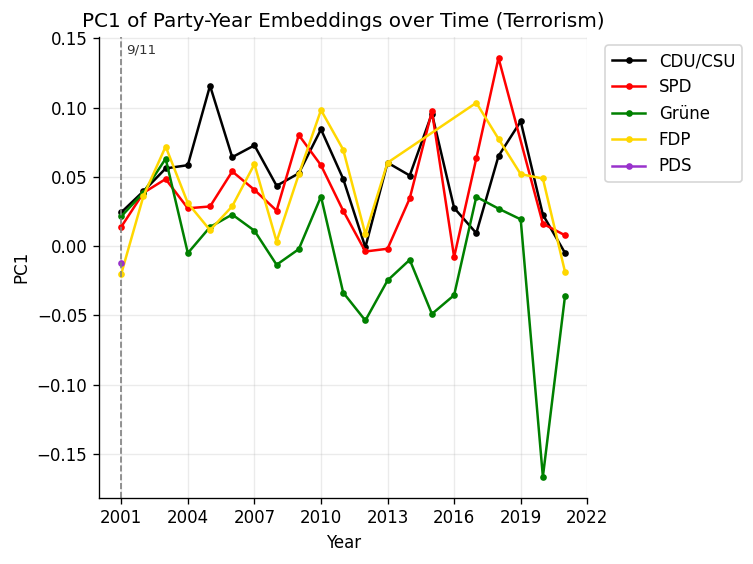

In [ ]:
plot_trajectory_1d(df_9_11, 2001, 'Terrorism', '9/11 terror attacks')

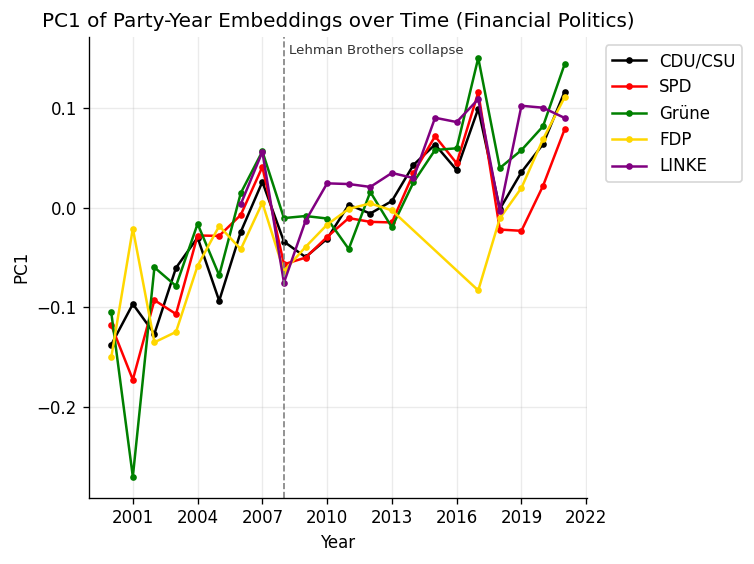

In [149]:
plot_trajectory_1d(df_financial_crisis, 2008, 'Financial Politics', 'Lehman Brothers collapse')

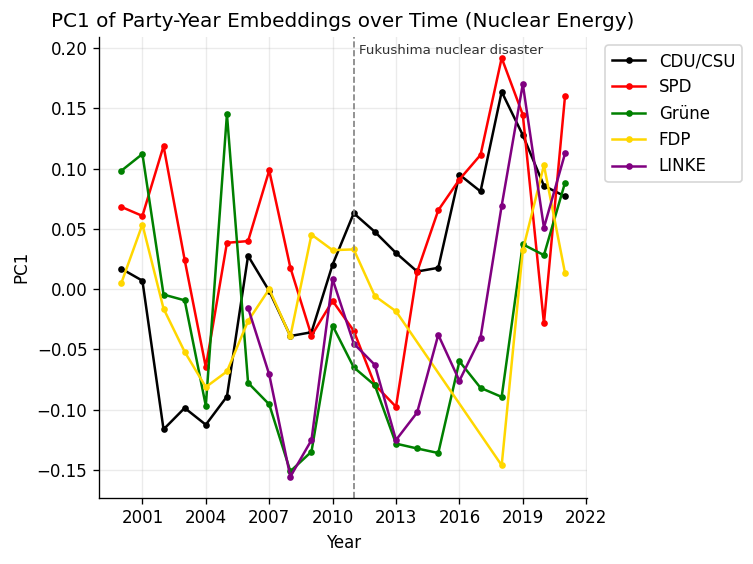

In [74]:
plot_trajectory_1d(df_fukushima, 2011, 'Nuclear Energy', 'Fukushima nuclear disaster')

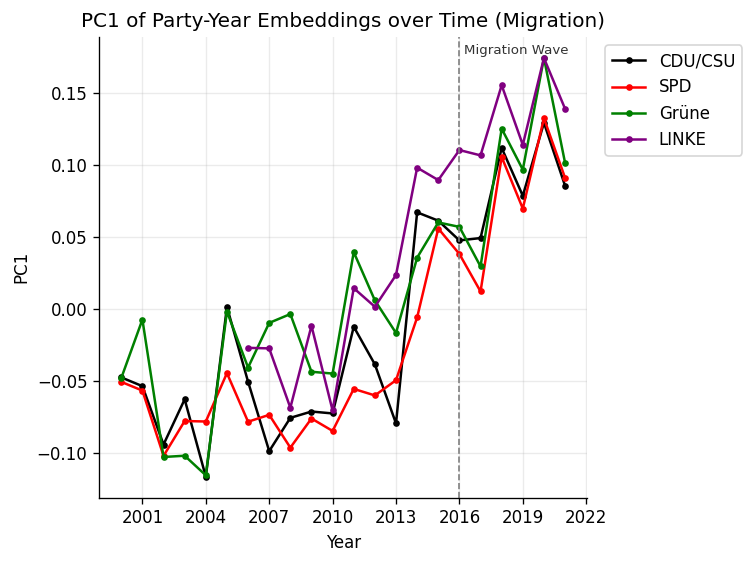

In [75]:
plot_trajectory_1d(df_migration, 2016, 'Migration', 'Migration Wave')

**PC1 over time.** Collapsing to one dimension makes the year-to-year path readable, and two patterns
come through — neither of them an event effect.

*Level differences between parties are stable.* On the terror topic the LINKE sits 0.1–0.2 below every
other party for the entire period, with the AfD joining it from 2019. That is a real and persistent
difference in how the ISAF mandate is talked about, but it is there long before and long after 2001.

*The common movement is time, not politics.* On the financial and migration topics all parties rise
together — migration climbs from about −0.10 in the early 2000s to about +0.15 by 2020 for everyone at
once. A parallel shift like that is the era effect already seen in part 1, and it is what the demeaned
version below is meant to remove.


To rule out that a shared, year-wide shift in language (rather than a party-specific move) is driving the pattern, we subtract each year's across-party mean from PC1 before plotting, so only each party's position relative to the others in that year remains.

In [76]:
def demean_by_year(df_traj, value_col="pc1"):
    """Subtracts the across-party mean per year from the given value column."""
    df_traj = df_traj.copy()
    year_means = df_traj.groupby("year")[value_col].transform("mean")
    df_traj[f"{value_col}_demeaned"] = df_traj[value_col] - year_means
    return df_traj

In [77]:
def plot_trajectory_1d_demeaned(df, year, topic, crisis):

    # aggregate the embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to one dimension
    pca_traj = PCA(n_components=1)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "pc1": pcs_traj[:, 0],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # subtract the across-party mean per year (to remove common, year-wide shifts)
    df_party_trajectories = demean_by_year(df_party_trajectories, value_col="pc1")

    fig, ax = plt.subplots()

    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]

        # skip parties with no speech in the event year itself
        if year not in subset["year"].values:
            continue

        ax.plot(subset["year"], subset["pc1_demeaned"], color=color, label=party, marker='o', markersize=3)

    # mark the event year and label it
    ax.axvline(year, color="grey", linestyle="--", linewidth=1)
    ax.annotate(crisis, (year, ax.get_ylim()[1]), xytext=(3, -10),
                textcoords="offset points", fontsize=8, color="0.2")

    # force integer year ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xlabel("Year")
    ax.set_ylabel("PC1 (demeaned per year)")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(f"PC1 of Party-Year Embeddings over Time, Demeaned ({topic})")
    plt.tight_layout()
    plt.show()

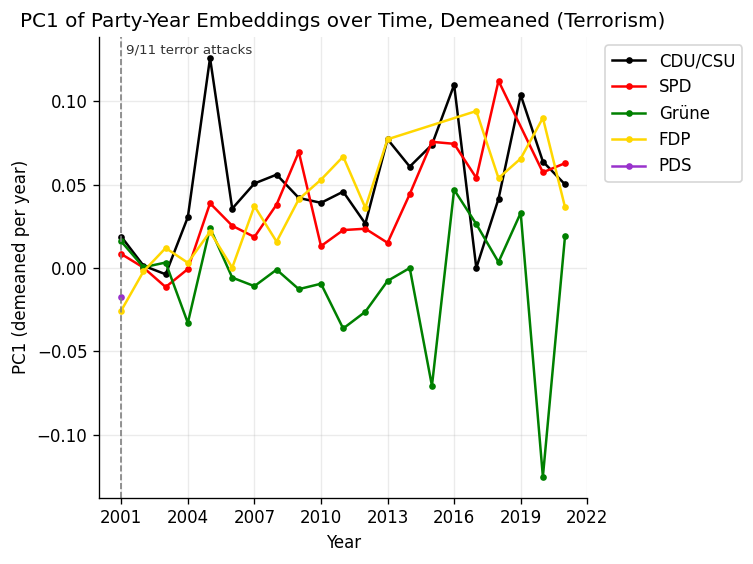

In [78]:
plot_trajectory_1d_demeaned(df_9_11, 2001, "Terrorism", '9/11 terror attacks')

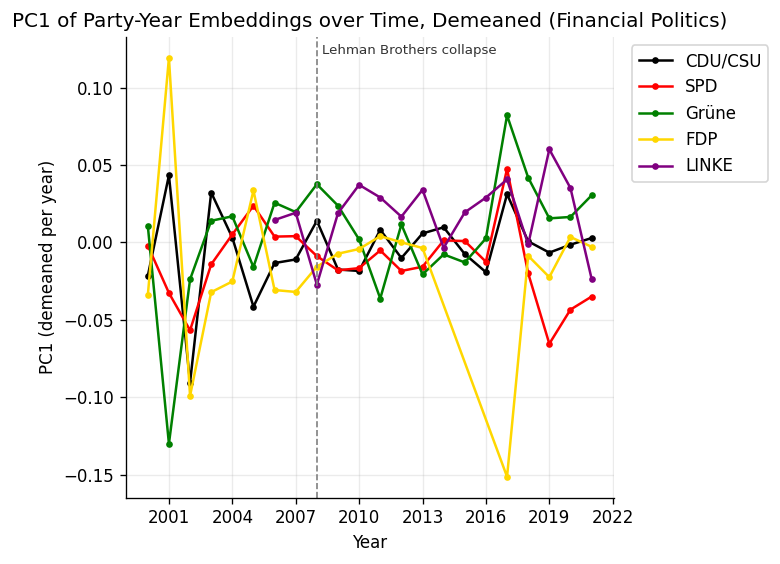

In [79]:
plot_trajectory_1d_demeaned(df_financial_crisis, 2008, "Financial Politics", 'Lehman Brothers collapse')

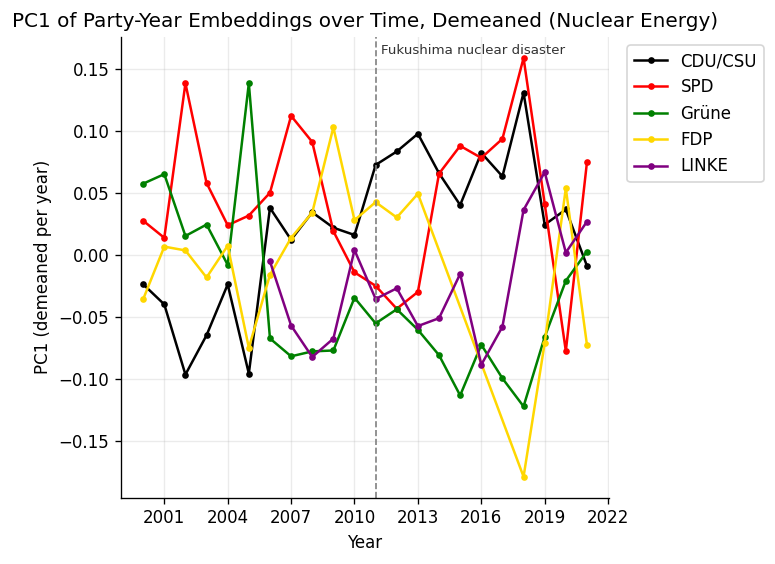

In [80]:
plot_trajectory_1d_demeaned(df_fukushima, 2011, "Nuclear Energy", 'Fukushima nuclear disaster')

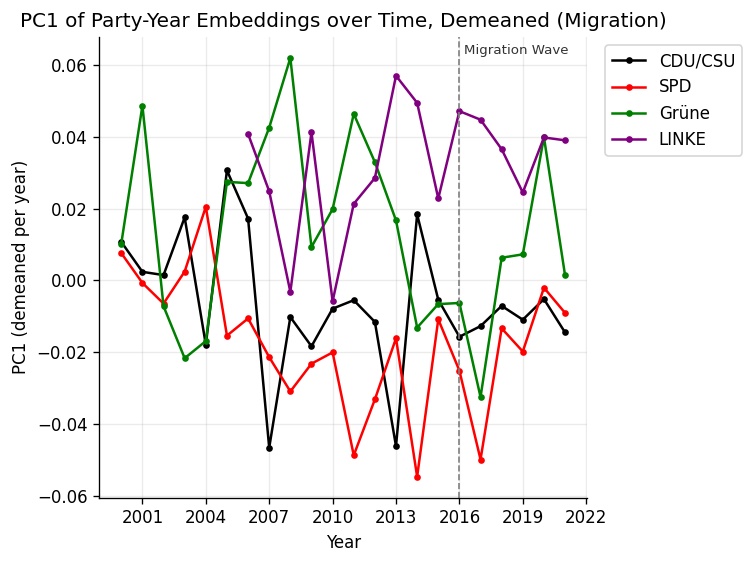

In [81]:
plot_trajectory_1d_demeaned(df_migration, 2016, "Migration", 'Migration Wave')

**Demeaned PC1.** Subtracting the cross-party mean of each year removes the common drift and leaves the ranking between parties, which is now stable and mostly plausible: on the terror topic the LINKE sits far below everyone else (roughly −0.05 to −0.23) while CDU/CSU, FDP and SPD stay above zero; on migration the LINKE and Grüne are consistently above the SPD and FDP, and the AfD enters high in 2017 before falling back toward zero by 2020. The nuclear topic stays noisy and its ordering flips repeatedly.

The event years still do not stand out, though — in none of the four topics does the dashed line coincide with a kink. Visual inspection of party trajectories, in 2D or 1D, raw or demeaned, does not detect the events. We therefore try two alternative approaches:
- instead of tracking whole parties, we focus on individual politicians who specialized in the respective topic
- instead of relying on a visual check, we compute the cosine similarity between consecutive embeddings and look for peaks in the resulting distance, indicating unusually large shifts.

In [115]:
def find_specialist_per_party(data, topic_name, year):
    """
    For a given topic and year: pick the politician with the most speeches on
    this topic per party (including name), restricted to politicians who
    actually spoke on this topic in the given event year.
    """
    topic_speeches = data[data["topic_emb_raw_name"] == topic_name]

    # only politicians active on this topic in the event year itself qualify
    active_in_year = set(
        topic_speeches.loc[topic_speeches["year"] == year, "politicianId"]
    )
    topic_speeches = topic_speeches[topic_speeches["politicianId"].isin(active_in_year)]

    specialists = {}
    for party, group in topic_speeches.groupby("party"):
        top_politician = group["politicianId"].value_counts().idxmax()
        top_name = group.loc[group["politicianId"] == top_politician, "politicianName"].iloc[0]
        specialists[party] = {"politicianId": top_politician, "name": top_name}

    return specialists

In [116]:
# the first (main) topic of each event defines its specialists
specialists_9_11 = find_specialist_per_party(df_embeddings_topics, TOPICS_9_11[0], 2001)
specialists_finance = find_specialist_per_party(df_embeddings_topics, TOPICS_FINANCE[0], 2008)
specialists_nuclear_energy = find_specialist_per_party(df_embeddings_topics, TOPICS_FUKUSHIMA[0], 2011)
specialists_migration = find_specialist_per_party(df_embeddings_topics, TOPICS_MIGRATION[0], 2016)

In [118]:
def get_specialist_trajectories(data, specialists):
    """specialists: Dict {party: {"politicianId": ..., "name": ...}} aus find_specialist_per_party."""
    politician_ids = [s["politicianId"] for s in specialists.values()]
    id_to_name = {s["politicianId"]: s["name"] for s in specialists.values()}

    df_specialists = data[data["politicianId"].isin(politician_ids)]
    df_traj = aggregate_by_mp_year(df_specialists)
    df_traj["politicianName"] = df_traj["politicianId"].map(id_to_name)
    return df_traj

In [119]:
df_specialists_9_11 = get_specialist_trajectories(df_9_11, specialists_9_11)
df_specialists_9_11

,politicianId,year,party,n_speeches,embedding,politicianName
0,11000489,2001,SPD,2,"[0.079166204, -0.122449614, 0.05259464, -0.019...",Gernot Erler
1,11000489,2002,SPD,1,"[0.05766705, -0.15619972, 0.063324325, -0.0263...",Gernot Erler
2,11000489,2003,SPD,2,"[0.070513226, -0.12641338, 0.078853965, -0.045...",Gernot Erler
3,11000489,2004,SPD,2,"[0.06208766, -0.12479927, 0.07558957, -0.00237...",Gernot Erler
4,11000489,2009,SPD,2,"[0.058541812, -0.15274373, 0.057768084, -0.052...",Gernot Erler
5,11000489,2010,SPD,2,"[0.065844506, -0.15831095, 0.04347298, -0.0388...",Gernot Erler
6,11000489,2011,SPD,1,"[0.051906686, -0.17466094, 0.038522404, -0.051...",Gernot Erler
7,11000489,2012,SPD,1,"[0.06908874, -0.17477067, 0.04612363, -0.04700...",Gernot Erler
8,11002053,2001,CDU/CSU,1,"[0.0398332, -0.12141645, 0.047952056, -0.03902...",Andreas Schockenhoff
9,11002053,2002,CDU/CSU,1,"[0.06775649, -0.11503122, 0.08299214, 0.015198...",Andreas Schockenhoff


In [120]:
df_specialists_finance = get_specialist_trajectories(df_financial_crisis, specialists_finance)
df_specialists_finance

,politicianId,year,party,n_speeches,embedding,politicianName
0,11000921,2000,PDS,1,"[0.105008624, -0.104357645, -0.029954134, -0.0...",Barbara Höll
1,11000921,2006,LINKE,1,"[0.09428888, -0.077313505, 0.037610184, -0.011...",Barbara Höll
2,11000921,2007,LINKE,2,"[0.04149736, -0.08038124, -0.00066547, -0.0069...",Barbara Höll
3,11000921,2008,LINKE,2,"[0.104723096, -0.10059087, -0.0128194755, -0.0...",Barbara Höll
4,11000921,2009,LINKE,2,"[0.114496514, -0.05786836, -0.0031456351, -0.0...",Barbara Höll
...,...,...,...,...,...,...
59,11003857,2013,LINKE,3,"[0.10169178, -0.06158549, -0.021588339, -0.026...",Axel Troost
60,11003857,2014,LINKE,4,"[0.11166624, -0.065381885, -0.015131699, -0.01...",Axel Troost
61,11003857,2015,LINKE,3,"[0.08100632, -0.07234293, 0.0045438553, -0.016...",Axel Troost
62,11003857,2016,LINKE,4,"[0.090264685, -0.07006645, -0.0054677315, -0.0...",Axel Troost


In [121]:
df_specialists_fukushima = get_specialist_trajectories(df_fukushima, specialists_nuclear_energy)
df_specialists_fukushima

,politicianId,year,party,n_speeches,embedding,politicianName
0,11003070,2003,CDU/CSU,1,"[0.09340047, -0.13639091, 0.060505424, -0.0232...",marie-luise dött
1,11003070,2006,CDU/CSU,1,"[0.093850054, -0.091889314, 0.030769605, -0.02...",marie-luise dött
2,11003070,2010,CDU/CSU,1,"[0.078189574, -0.08504295, 0.018798701, -0.037...",marie-luise dött
3,11003070,2011,CDU/CSU,4,"[0.09187102, -0.11195911, 0.0381723, -0.017886...",marie-luise dött
4,11003070,2019,CDU/CSU,2,"[0.10895098, -0.12462519, 0.037627358, -0.0193...",marie-luise dött
5,11003450,2001,SPD,1,"[0.115439005, -0.12431671, 0.046310224, -0.033...",Ulrich Kelber
6,11003450,2004,SPD,1,"[0.105739, -0.12452609, 0.010788814, -0.009417...",Ulrich Kelber
7,11003450,2006,SPD,1,"[0.08627636, -0.09736979, 0.02540849, -0.03172...",Ulrich Kelber
8,11003450,2009,SPD,1,"[0.07380264, -0.10769714, 0.028285587, 0.00319...",Ulrich Kelber
9,11003450,2010,SPD,14,"[0.09212219, -0.12145165, 0.032978535, -0.0260...",Ulrich Kelber


In [122]:
df_specialists_migration = get_specialist_trajectories(df_migration, specialists_migration)
df_specialists_migration

,politicianId,year,party,n_speeches,embedding,politicianName
0,11001023,2000,PDS,6,"[0.019995324, -0.14479679, 0.08593189, 0.01697...",Ulla Jelpke
1,11001023,2001,PDS,3,"[0.014566686, -0.14010738, 0.07953859, 0.01412...",Ulla Jelpke
2,11001023,2006,LINKE,4,"[0.0032662828, -0.13357493, 0.09007467, -0.007...",Ulla Jelpke
3,11001023,2007,LINKE,6,"[0.02310902, -0.14631854, 0.10128971, 0.003478...",Ulla Jelpke
4,11001023,2008,LINKE,2,"[0.045828428, -0.14256574, 0.08438596, 0.02303...",Ulla Jelpke
...,...,...,...,...,...,...
58,11003589,2014,CDU/CSU,7,"[0.03260163, -0.12393165, 0.095013365, 0.02150...",Stephan Mayer
59,11003589,2015,CDU/CSU,5,"[0.036661588, -0.1505655, 0.097410485, 0.03593...",Stephan Mayer
60,11003589,2016,CDU/CSU,10,"[0.04955908, -0.13128056, 0.08646698, 0.020973...",Stephan Mayer
61,11003589,2017,CDU/CSU,5,"[0.03464604, -0.13882908, 0.09931757, 0.026321...",Stephan Mayer


In [ ]:
def plot_trajectory_1d_specialists(df, year, topic, crisis, specialists):
    df_agg = aggregate_by_mp_year(df)

    stack = np.stack(df_agg['embedding'])
    pca_traj = PCA(n_components=1)
    pcs_traj = pca_traj.fit_transform(stack)

    df_traj = pd.DataFrame({
        "pc1": pcs_traj[:, 0],
        "politicianId": df_agg.politicianId,
        "party": df_agg.party,
        "year": df_agg.year
    })
    df_traj = df_traj.sort_values(["politicianId", "year"])

    fig, ax = plt.subplots(figsize=(8, 5))

    for party, info in specialists.items():
        politician_id = info["politicianId"]
        name = info["name"]
        subset = df_traj[df_traj["politicianId"] == politician_id]

        # skip specialists with no speech in the event year itself
        if year not in subset["year"].values:
            continue

        # connecting line across all years, in the color of the party 
        ax.plot(subset["year"], subset["pc1"], color=party_colors[party],
                lw=1, alpha=0.8, zorder=2)

        # markers colored by the MP's ACTUAL party in that year, so a party
        # switch (e.g. PDS -> LINKE) is visible as a color change
        for actual_party, g in subset.groupby("party"):
            ax.scatter(g["year"], g["pc1"], color=party_colors.get(actual_party, "grey"),
                       s=20, zorder=3)

        # one legend entry per specialist, labeled by the party they were selected for
        ax.plot([], [], color=party_colors[party], marker='o', markersize=4,
                label=f"{party} ({name})")

    # mark the event year and label it
    ax.axvline(year, color="grey", linestyle="--", linewidth=1)
    ax.annotate(crisis, (year, ax.get_ylim()[1]), xytext=(3, -10),
                textcoords="offset points", fontsize=8, color="0.2")

    # force integer year ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xlabel("Year")
    ax.set_ylabel("PC1")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    ax.set_title(f"PC1 of Specialist MP Embeddings over Time ({topic})")
    plt.tight_layout()
    plt.show()

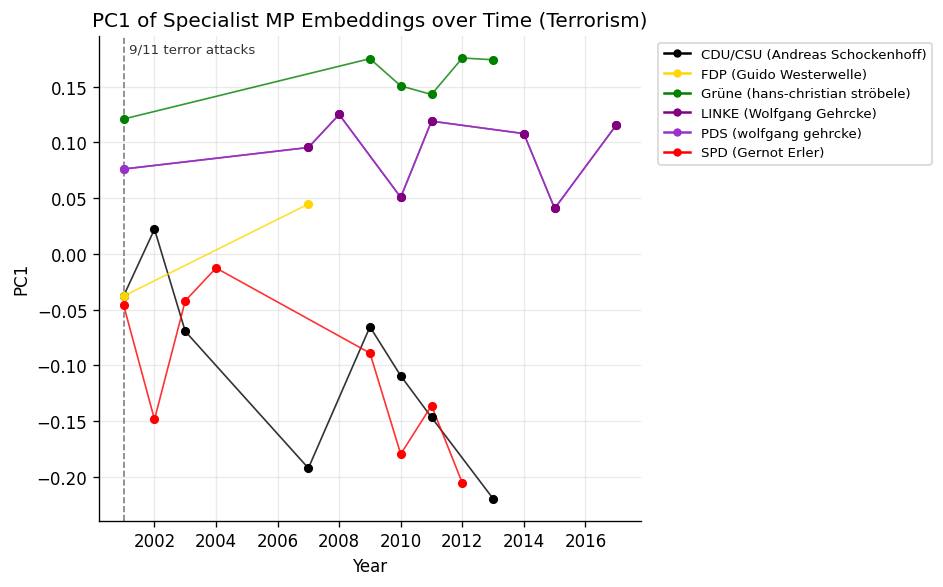

In [145]:
plot_trajectory_1d_specialists(df_specialists_9_11, 2001, 'Terrorism', '9/11 terror attacks', specialists_9_11)

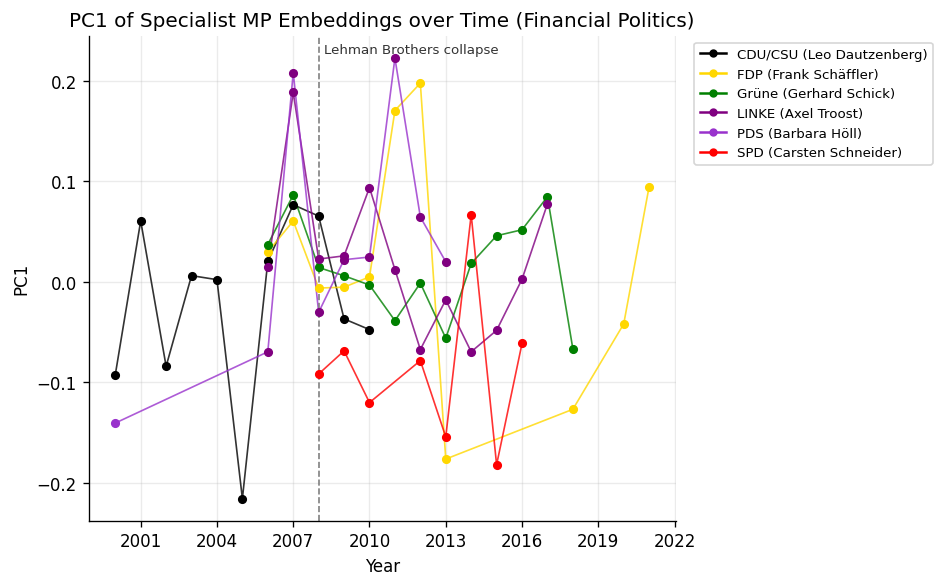

In [146]:
plot_trajectory_1d_specialists(df_specialists_finance, 2008, 'Financial Politics', 'Lehman Brothers collapse', specialists_finance)

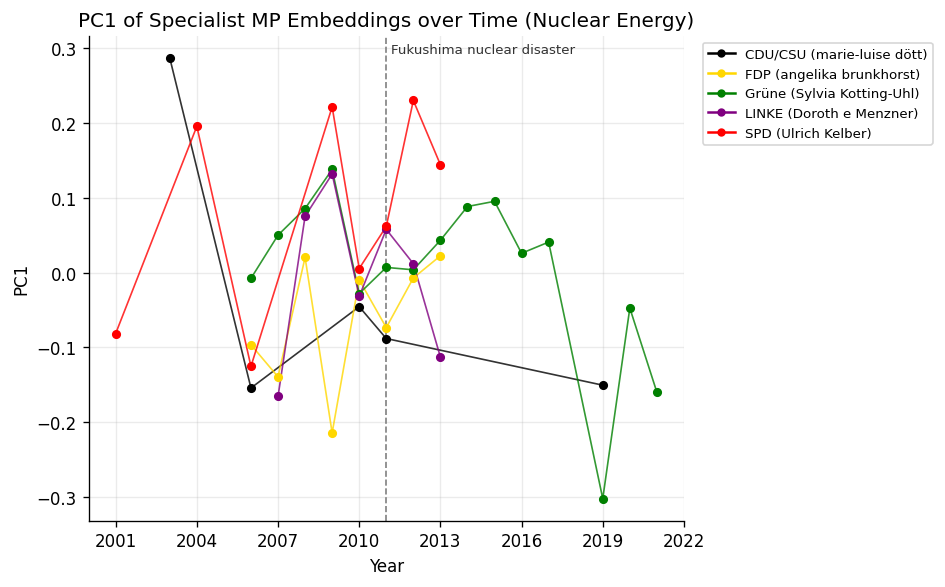

In [147]:
plot_trajectory_1d_specialists(df_specialists_fukushima, 2011, 'Nuclear Energy', 'Fukushima nuclear disaster', specialists_nuclear_energy)

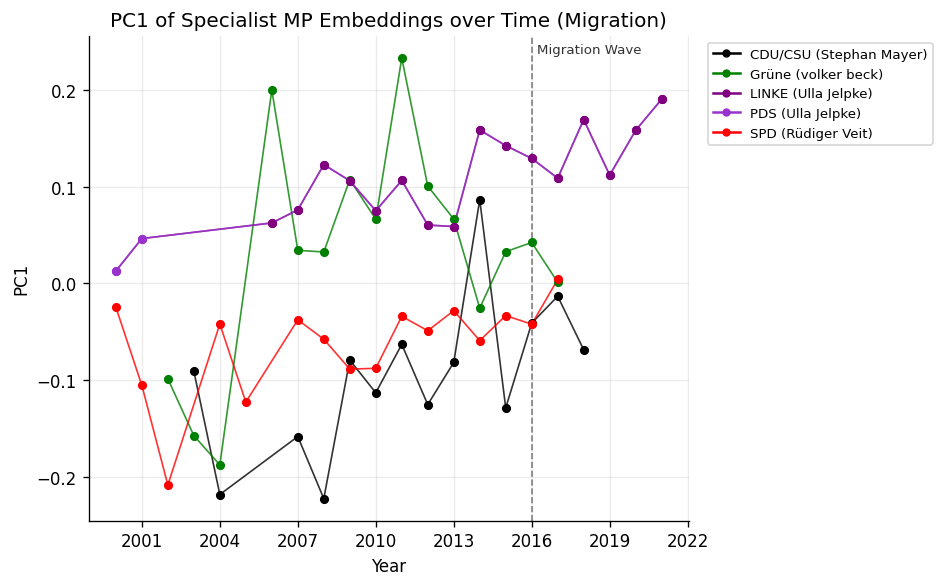

In [148]:
plot_trajectory_1d_specialists(df_specialists_migration, 2016, 'Migration', 'Migration Wave', specialists_migration)

**Specialist MPs.** One line per party, following the MP with the most speeches on that topic. The series
are short and gappy — a specialist only appears in the years they actually spoke — and the event years
again pass without a visible break.

Two things to keep in mind before reading anything into these panels. The PCA is refitted on the
specialists' own embeddings, so PC1 here is not the PC1 of the plots above. And in the some panels the LINKE and PDS entries resolve to the same `politicianId`  —  MPs whose party label changed over time.

### Cosine Similarity

In [193]:
def compute_distance_series(df, topic):
    """
    Aggregates the (already topic-filtered) speeches by party and year,
    then computes the cosine distance between each party's embedding
    in consecutive years.
    """
    df_agg = aggregate_by_party_year(df)
    df_agg = df_agg.sort_values(["party", "year"])

    records = []
    for party, color in party_colors.items():
        subset = df_agg[df_agg["party"] == party].sort_values("year")
        if len(subset) < 2:
            continue

        embeddings = np.stack(subset["embedding"])
        years = subset["year"].values

        for i in range(1, len(embeddings)):
            sim = cosine_similarity(embeddings[i-1].reshape(1, -1), embeddings[i].reshape(1, -1))[0, 0]
            distance = 1 - sim
            records.append({
                "party": party,
                "year": years[i],
                "distance": distance
            })

    return pd.DataFrame(records)

def plot_distance_series(df, topic, crisis, event_year):
    df_dist = compute_distance_series(df, topic)

    fig, ax = plt.subplots()

    for party, color in party_colors.items():
        subset = df_dist[df_dist["party"] == party]

        # skip parties with no distance value in the event year itself
        if event_year not in subset["year"].values:
            continue

        ax.plot(subset["year"], subset["distance"], color=color, label=party, marker='o', markersize=3)

    ax.axvline(event_year, color="grey", linestyle="--", linewidth=1)
    ax.annotate(crisis, (event_year, ax.get_ylim()[1]), xytext=(3, -10),
                textcoords="offset points", fontsize=8, color="0.2")

    ax.set_xlabel("Year")
    ax.set_ylabel("Cosine Distance to Previous Year")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(f"Year-over-Year Embedding Distance ({topic})")
    ax.set_xticks(sorted(df_dist["year"].unique()))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df_dist

There's no distance value for 2001 itself, because we're looking at year-over-year change. So the first value is for 2002. Therefor we leave out the 9/11 terror attacks for this part of the analysis. 

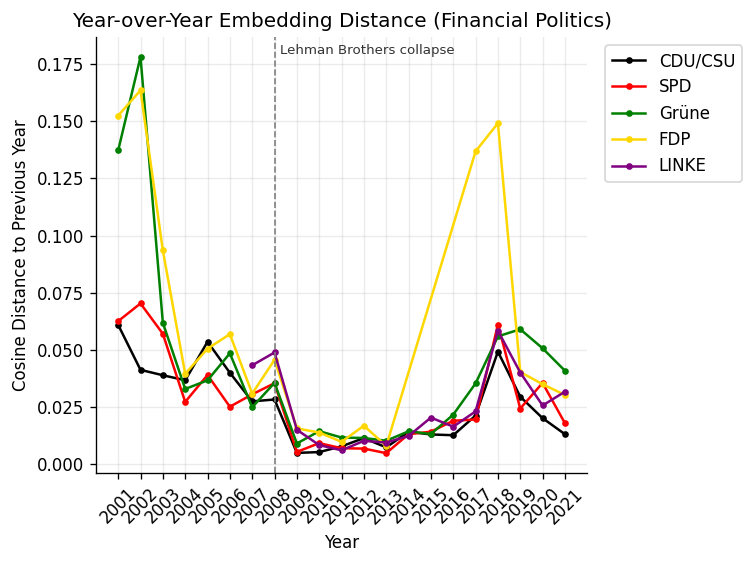

,party,year,distance
0,CDU/CSU,2001,0.060981
1,CDU/CSU,2002,0.041341
2,CDU/CSU,2003,0.038979
3,CDU/CSU,2004,0.036788
4,CDU/CSU,2005,0.053598
...,...,...,...
96,AfD,2018,0.107360
97,AfD,2019,0.045500
98,AfD,2020,0.026481
99,AfD,2021,0.033036


In [198]:
df_dist_finance = plot_distance_series(df_financial_crisis, "Financial Politics",'Lehman Brothers collapse', 2008)
df_dist_finance

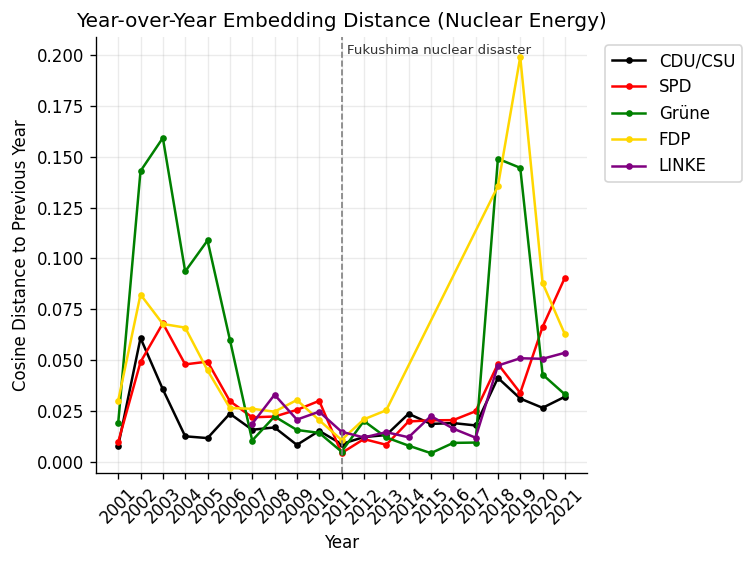

,party,year,distance
0,CDU/CSU,2001,0.007793
1,CDU/CSU,2002,0.060870
2,CDU/CSU,2003,0.035662
3,CDU/CSU,2004,0.012572
4,CDU/CSU,2005,0.011685
...,...,...,...
95,AfD,2019,0.056605
96,AfD,2020,0.036153
97,AfD,2021,0.027436
98,PDS,2001,0.015827


In [199]:
df_dist_fukushima = plot_distance_series(df_fukushima, "Nuclear Energy", 'Fukushima nuclear disaster', 2011)
df_dist_fukushima

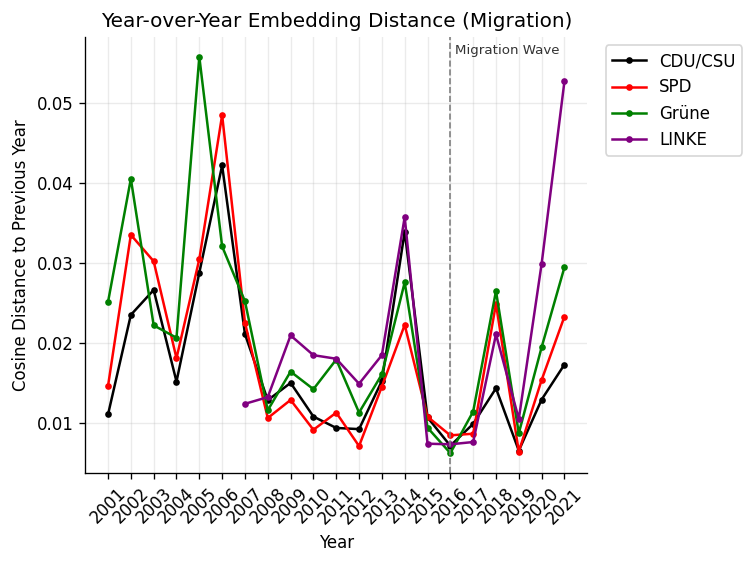

,party,year,distance
0,CDU/CSU,2001,0.011078
1,CDU/CSU,2002,0.023537
2,CDU/CSU,2003,0.026655
3,CDU/CSU,2004,0.015196
4,CDU/CSU,2005,0.028815
...,...,...,...
97,AfD,2019,0.007801
98,AfD,2020,0.010756
99,AfD,2021,0.028880
100,PDS,2001,0.031703


In [201]:
df_dist_migration = plot_distance_series(df_migration, "Migration", 'Migration Wave', 2016)
df_dist_migration

**Year-over-year distance.** This was meant to replace the eyeball test with a number: a crisis should
show up as a spike in how far a party's yearly embedding moves. It does not. If anything the pattern runs
the other way — the distances *collapse* exactly when an event fills the agenda. On the nuclear topic 2011
is the flattest year in the whole series, with every party between 0.005 and 0.015; on the financial topic
the distances drop sharply after 2008 and stay low through 2013; on migration the minimum is 2015–2016.

The reason is sample size rather than politics. A party-year built from many speeches gives a stable mean,
so consecutive high-volume years look similar, while a party-year built from five speeches is decided by
whichever debates fell into it and lands far from its neighbours. That is why the large distances sit in
the thin years at both ends of each series.

One artefact to be aware of: the distance is computed between consecutive *rows*, not consecutive years.
The FDP was out of parliament from 2013 to 2017, so its "2017" point is the distance across a four-year
gap — that, and not a shift in position, is the large FDP excursion in the financial and nuclear panels.
The AfD's first point has the same problem.

## 3. Party anchors — positions on an anchored axis

Part 2 asked where PCA puts the parties, and found that the dominant direction tracks era and
government/opposition rather than policy. This part replaces that with an axis we choose: two
parties are named as poles, and everyone else is projected onto the line between them.
Sample sizes behind these points are shown by marker size.

- yearly mean is subtracted so a drift shared by all parties cannot look like movement;
- the axis is estimated on the years before the event so the ruler does not move with the data; and the result is rescaled so the two anchor parties sit at 0 and 1 in that reference period, which makes a value of 0.4 readable as "40% of the way from one party's position to the other's"

In [54]:
def positions(topic_names, left, right, ref_years):
    "Party-year positions on the left->right axis, rescaled so left=0 and right=1 before the event."
    d = df[df.topic_emb_full_name.isin(topic_names)]

    # 1. aggregate to party-year, no threshold
    py = pd.DataFrame([dict(party=p, year=y, n=len(g),
                            E=np.mean(np.stack(g.E.to_numpy()), axis=0))
                       for (p, y), g in d.groupby(["party", "year"])])

    # a year with one party is useless: the yearly mean is that party, so demeaning gives 0
    per_year = py.groupby("year").size()
    lonely = per_year[per_year < 2].index.tolist()
    if lonely:
        print(f"years with only one party, dropped: {lonely}")
        py = py[~py.year.isin(lonely)]

    # 2. subtract the yearly mean
    ymu = {y: np.mean(np.stack(g.E.to_numpy()), axis=0) for y, g in py.groupby("year")}
    py["Ed"] = [e - ymu[y] for e, y in zip(py.E, py.year)]

    # 3. axis from the reference (pre-event) years only
    ref = py[py.year.isin(ref_years)]
    for anchor in (left, right):
        if not (ref.party == anchor).any():
            raise ValueError(f"{anchor} has no speech in the reference years {list(ref_years)}")
    a = (np.mean(np.stack(ref.loc[ref.party == right, "Ed"].to_numpy()), axis=0)
         - np.mean(np.stack(ref.loc[ref.party == left,  "Ed"].to_numpy()), axis=0))
    axis = a / np.linalg.norm(a)

    # 4. project, then rescale so the anchors sit at 0 and 1 in the reference period
    py["raw"] = [float(e @ axis) for e in py.Ed]
    lo = py.loc[py.year.isin(ref_years) & (py.party == left),  "raw"].mean()
    hi = py.loc[py.year.isin(ref_years) & (py.party == right), "raw"].mean()
    py["pos"] = (py.raw - lo) / (hi - lo)
    return py.sort_values(["party", "year"])


def plot_positions(py, event_year, left, right, title):
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.axhline(0, color=PARTY_COLORS.get(left, "0.4"), ls=":", lw=1.4)
    ax.axhline(1, color=PARTY_COLORS.get(right, "0.4"), ls=":", lw=1.4)
    ax.axvline(event_year, color="#c0392b", ls="--", lw=1.5)
    for p, g in py.groupby("party"):
        g = g.sort_values("year")
        col = PARTY_COLORS.get(p, "grey")
        # break the line where a year is missing, so a gap is not drawn as a smooth move
        run = []
        for r in g.itertuples():
            if run and r.year - run[-1][0] > 1:
                ax.plot(*zip(*run), "-", color=col, lw=1.8)
                run = []
            run.append((r.year, r.pos))
        if len(run) > 1:
            ax.plot(*zip(*run), "-", color=col, lw=1.8)
        # marker size shows how many speeches are behind the point
        ax.scatter(g.year, g.pos, s=6 + 1.6 * g.n, color=col, zorder=4, label=p,
                   edgecolor="white", linewidth=.6)
    ax.set_xlabel("year")
    ax.set_ylabel(f"position on the {left} → {right} axis\n(0 = {left}, 1 = {right} before the event)")
    ax.set_title(title + "   (marker size = speeches behind the point)", loc="left", fontsize=10)
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    return ax

#### Fukushima — did the Union move toward the Greens?

The clearest test case, because the answer is documented outside the corpus: after March 2011
the CDU/CSU reversed course and legislated the nuclear phase-out it had extended only months
earlier. If the embeddings carry policy content, the Union should move upward after 2011. The
axis is estimated on 2005–2010.

speeches per party-year:
party  AfD  CDU/CSU  FDP  Grüne  LINKE  PDS  SPD
year                                            
2000     0       32   14      9      0   13   26
2001     0       27   10      9      0   10   21
2002     0        4    2      1      0    1    2
2003     0       14    6      4      0    0    5
2004     0       17    2      5      0    0    7
2005     0       23    5      3      0    0    8
2006     0       18   10     33      9    0   11
2007     0       17    9     24     10    0   15
2008     0       17    5     42     10    0   10
2009     0       17    6     23     15    0    4
2010     0       48   24     78     34    0   67
2011     0       44   22     58     42    0   50
2012     0       20   20     28     22    0   32
2013     0       16   11     33     17    0   26
2014     0       15    0     62     16    0   14
2015     0       13    0     45      9    0    8
2016     0       23    0     42     27    0   19
2017     0       10    0     29     17    0 

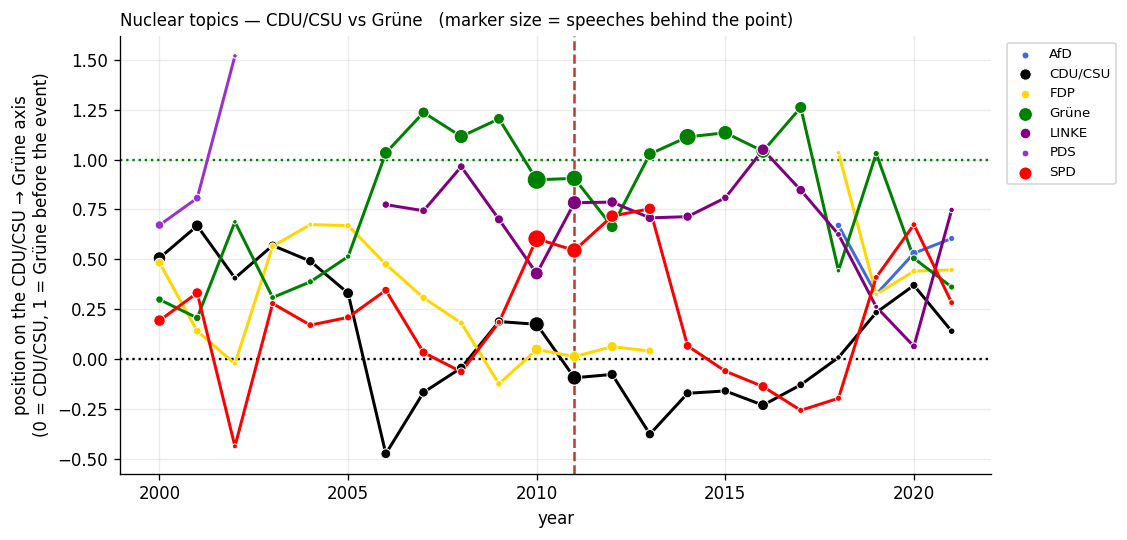

         2007-2010  2012-2015  shift
party                               
CDU/CSU       0.04      -0.20  -0.23
FDP           0.10       0.05  -0.05
Grüne         1.11       0.98  -0.13
LINKE         0.71       0.75   0.04
SPD           0.19       0.37   0.18


In [55]:
NUCLEAR = TOPICS_FUKUSHIMA

py_nuc = positions(NUCLEAR, left="CDU/CSU", right="Grüne", ref_years=range(2005, 2011))
print("speeches per party-year:")
print(py_nuc.pivot(index="year", columns="party", values="n").fillna(0).astype(int).to_string())

plot_positions(py_nuc, 2011, "CDU/CSU", "Grüne", "Nuclear topics — CDU/CSU vs Grüne")
plt.savefig("fig_fukushima.png", dpi=150, bbox_inches="tight"); plt.show()

before = py_nuc[py_nuc.year.between(2007, 2010)].groupby("party").pos.mean()
after  = py_nuc[py_nuc.year.between(2012, 2015)].groupby("party").pos.mean()
print(pd.DataFrame({"2007-2010": before, "2012-2015": after,
                    "shift": after - before}).round(2).to_string())

*Interpretation.* Read the plot from 2006 onwards. Before that the ordering is unstable and
implausible — in 2000–2002 the CDU/CSU sits between 0.5 and 0.67 while the Grüne sit between 0.30
and 0.68, and a single PDS year reaches 1.52 — which is a warning, not a finding: the axis is
estimated on 2005–2010 and does not transport back into the red-green years. From 2006 on the
ranking is stable and plausible: Grüne mostly between 0.9 and 1.27, LINKE between 0.7 and 1.05,
and SPD, FDP and Union at or below 0.3. So the direction does separate the parties.

The hypothesis still fails. Comparing 2007–2010 with 2012–2015, the Union does not move toward the
Greens after Fukushima; it moves away, from 0.04 to −0.20 (shift −0.23). The Grüne themselves drop
slightly (1.11 → 0.98) and the LINKE barely move (0.71 → 0.75). The only party moving clearly
upward is the SPD (0.19 → 0.37), and its timing gives the likely reason: it sits between 0.54 and
0.76 while fighting the lifetime extension from the opposition benches in 2010–2013, and falls
below zero once it enters the grand coalition in 2014. What the axis tracks looks more like an
opposition-versus-government register than a position on nuclear power.

That fits what happened to the topic. Once the phase-out became consensus the nuclear debate turned
into waste storage and grid questions, and there the Union speaks as the government that has to
implement it. The Merkel Wende is a policy reversal that left almost no trace in plenary language,
which is a genuine limit of the method rather than a result about the CDU/CSU.

Two caveats from the speech counts printed above the figure: 2002–2005 and 2018–2021 are thin for
every party, several party-years resting on fewer than ten speeches, and the LINKE only enters this
topic in 2006, the AfD in 2018 — so the ends of the lines carry much less weight than the middle.

#### Migration — where do the parties sit relative to the AfD?

The AfD only enters the Bundestag in 2017, so the axis has to be estimated *after* the event
rather than before it. That weakens the reading considerably: we can see the ordering of the
parties from 2017 onward, but not how they stood relative to a party that did not yet exist.

Anchors: Grüne und AfD

speeches per party-year:
party  AfD  CDU/CSU  FDP  Grüne  LINKE  PDS  SPD
year                                            
2000     0       29   29     22      0   14   30
2001     0       23    8      8      0    5   17
2002     0       10    3      9      0    4    7
2003     0       41    8      8      0    0   23
2004     0       31   12      7      0    0   18
2005     0       11    6      8      0    0   10
2006     0       17   11     18     16    0   12
2007     0       21   11     23     36    0   21
2008     0       23   12     30     23    0   23
2009     0       20   16     18     19    0   18
2010     0       29   17     19     27    0   16
2011     0       40   26     40     22    0   29
2012     0       24   21     26     20    0   24
2013     0       30   16     24     24    0   20
2014     0       51    0     62     43    0   48
2015     0      100    0     87     61    0   59
2016     0       76    0     69     45    0   49
2017     9       28    7     27     18    0 

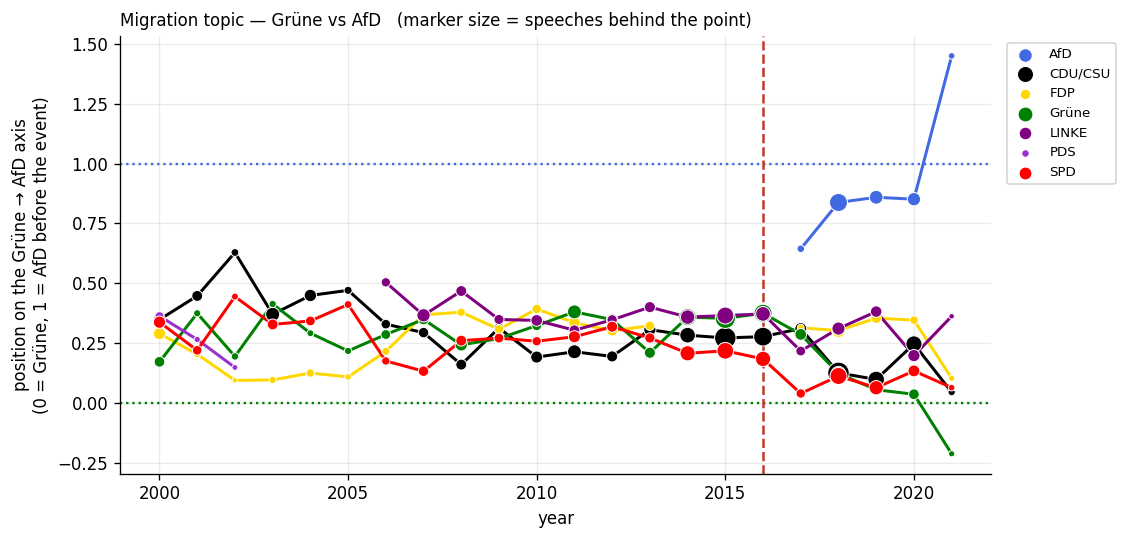

In [56]:
MIGRATION = TOPICS_MIGRATION

py_mig = positions(MIGRATION, left="Grüne", right="AfD", ref_years=range(2018, 2022))
print("speeches per party-year:")
print(py_mig.pivot(index="year", columns="party", values="n").fillna(0).astype(int).to_string())

plot_positions(py_mig, 2016, "Grüne", "AfD", "Migration topic — Grüne vs AfD")
plt.savefig("fig_migration.png", dpi=150, bbox_inches="tight"); plt.show()

*Interpretation.* The AfD separates cleanly, sitting at 0.64–0.86 from 2017 while every other
party stays between 0.0 and 0.5. But look at what that means: before 2017 all parties, the Grüne
included, sit bunched at 0.2–0.4 with no stable ordering between them. The axis has not found a
migration-policy scale on which the house can be ranked — it has found "AfD language versus
everyone else". By this measure the CDU/CSU is no closer to the AfD than the SPD is.

Two things not to over-read. The whole left half of the plot lies outside the reference period,
so the pre-2017 positions are projections onto a ruler built from years these parties had not yet
reached. And the 2021 endpoints (Grüne at −0.21, AfD at 1.45) rest on five and six speeches — the
electoral term ends in September, so the year is a stub.

## 4. Topic frequencies

Does an event change how much is said about a topic at all? This part never touches the embedding
vectors — only the topic labels and the speech counts behind them.

In [57]:
EVENTS = [
    #Afghanistan topics stand in for 9/11, since corpus records the parliamentary consequences rather than the attack
    dict(date="2001-09-11", label="9/11 terror attacks", kind="crisis", topics=TOPICS_9_11),
    dict(date="2008-09-15", label="Lehman collapse / financial crisis", kind="crisis", topics=TOPICS_FINANCE),
    dict(date="2011-03-11", label="Fukushima nuclear disaster", kind="crisis", topics=TOPICS_FUKUSHIMA),
    dict(date="2016-01-01", label="Migration scepticism (post-Cologne NYE)", kind="crisis", topics=TOPICS_MIGRATION),
]

for ev in EVENTS:
    ev["year"] = int(ev["date"][:4])
#checks that every name still exists in the data, so a re-run of the topic model would raise an error rather than silently analysing nothing.
unknown = {t for ev in EVENTS for t in ev["topics"]} - set(ALL_TOPICS)
if unknown:
    raise ValueError(f"topic name(s) not found in the data: {unknown}")
print("all topic names found in the data\n")

for ev in EVENTS:
    n = df.topic_emb_full_name.isin(ev["topics"]).sum()
    print(f"{ev['date']}  {ev['label']}")
    for t in ev["topics"]:
        print(f"     - {t}")
    print(f"     {n:,} speeches in total\n")

all topic names found in the data

2001-09-11  9/11 terror attacks
     - isaf-mandats/isaf-mission/karzai
     1,069 speeches in total

2008-09-15  Lehman collapse / financial crisis
     - pfandbrief/vermögensanlagen/kapitalanlagegesetzbuch
     1,624 speeches in total

2011-03-11  Fukushima nuclear disaster
     - schwarzelühr-sutter/reaktorsicherheit/reaktoren
     - entsorgungskonzept/salzstocks/sellafield
     1,744 speeches in total

2016-01-01  Migration scepticism (post-Cologne NYE)
     - mehrstaatigkeit/dublin-ii-verordnung/optionspflicht
     2,913 speeches in total



The four events differ in how much text stands behind them: **1,069** speeches for 9/11 (one topic),
**1,624** for Lehman (one), **1,744** for Fukushima (two) and **2,913** for migration (one). Small
topics move sharply from year to year simply because a handful of debates land in one year rather
than the next, so the thinner events are read for their level, not for their wiggles.

These counts are larger than the frames used in part 2 for the same events. The reason is the column:
this part matches on `topic_emb_full_name`, where every speech carries a topic, while part 2 filters
the 9/11 and migration frames on `topic_emb_raw_name`, which leaves the originally unassigned speeches
out (732 and 2,651 rows there, against 1,069 and 2,913 here). The financial and nuclear frames use the
full column in both parts and match exactly.

### Does attention change around the event?

Two views per event.

**Attention over time.** The share of all speeches in a year that fall on the
event's topics. If a crisis reorganises the agenda, this is where it shows up most directly.

**Who is doing the talking.** For each party, the share of *its own* speeches
devoted to those topics, in the three years before and the three years after the event. Using
each party's own denominator means a party that simply speaks more often does not appear more
interested.

**Share of each party's speeches on topic**

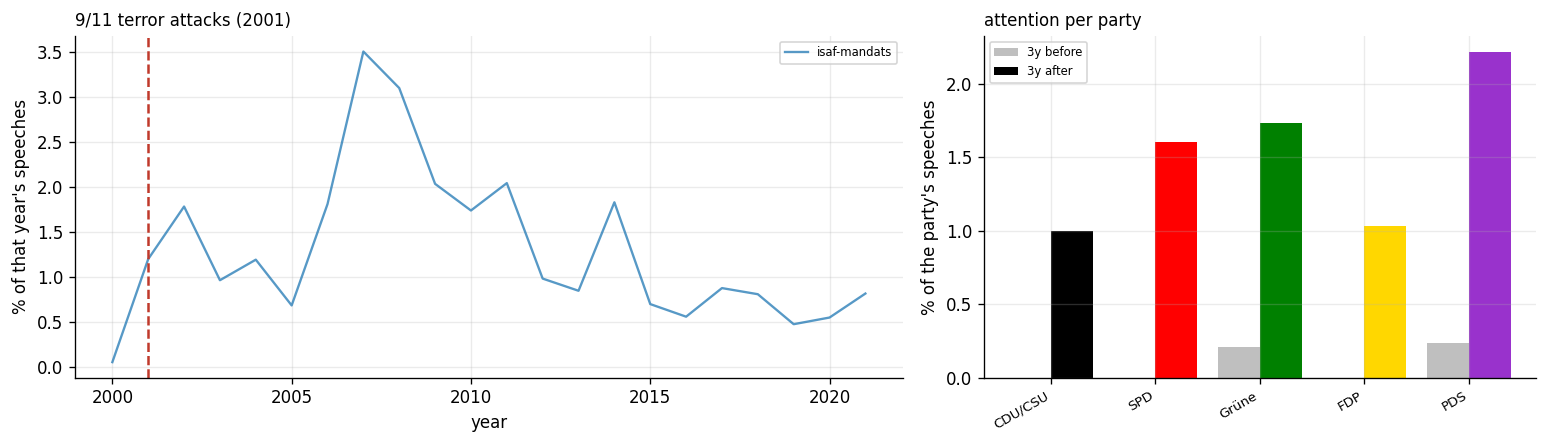

share of each party's speeches on these topics, % — 9/11 terror attacks
         isaf-mandats
party                
AfD              0.72
CDU/CSU          1.29
FDP              1.34
Grüne            1.36
LINKE            1.45
PDS              1.28
SPD              1.27 



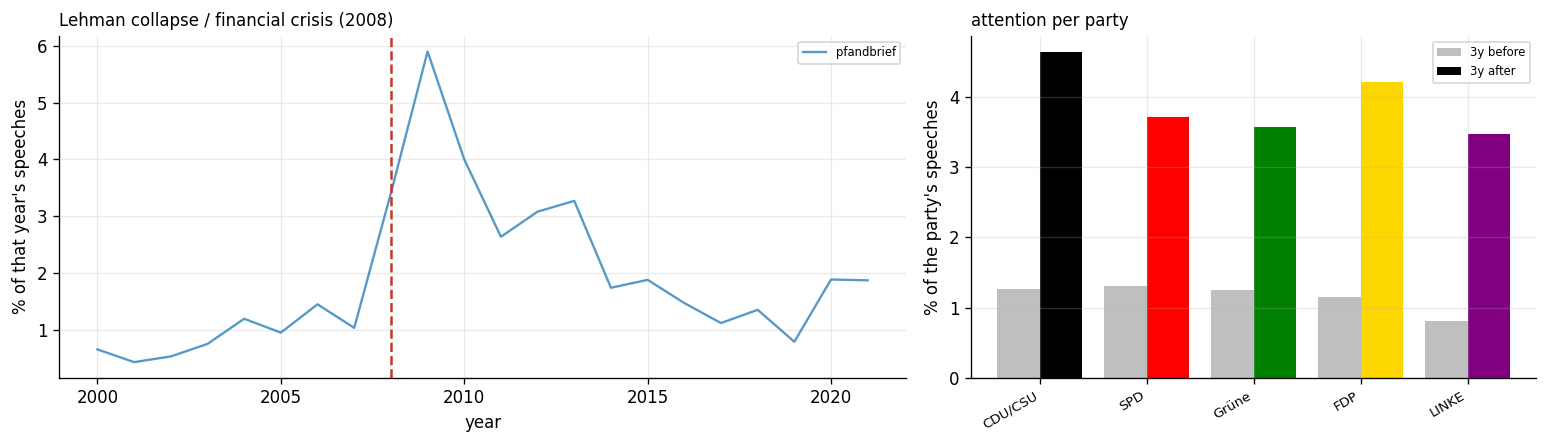

share of each party's speeches on these topics, % — Lehman collapse / financial crisis
         pfandbrief
party              
AfD            1.21
CDU/CSU        2.05
FDP            2.11
Grüne          1.84
LINKE          1.97
PDS            0.36
SPD            2.15 



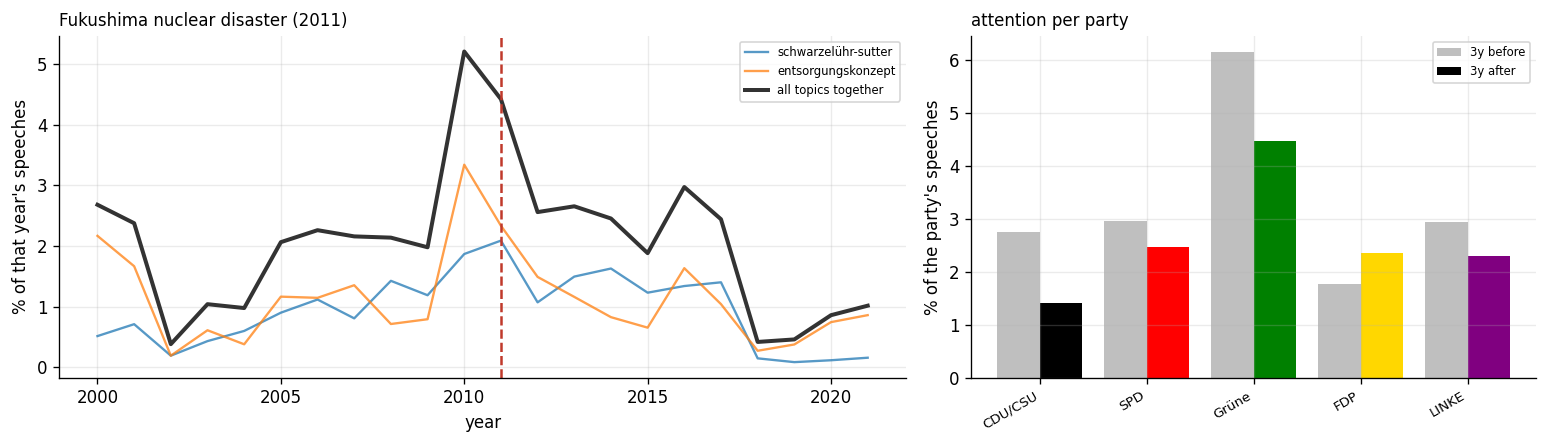

share of each party's speeches on these topics, % — Fukushima nuclear disaster
         entsorgungskonzept  schwarzelühr-sutter
party                                           
AfD                    0.68                 0.30
CDU/CSU                1.23                 0.44
FDP                    1.07                 0.43
Grüne                  1.10                 2.57
LINKE                  1.14                 1.12
PDS                    1.46                 0.73
SPD                    1.28                 0.64 



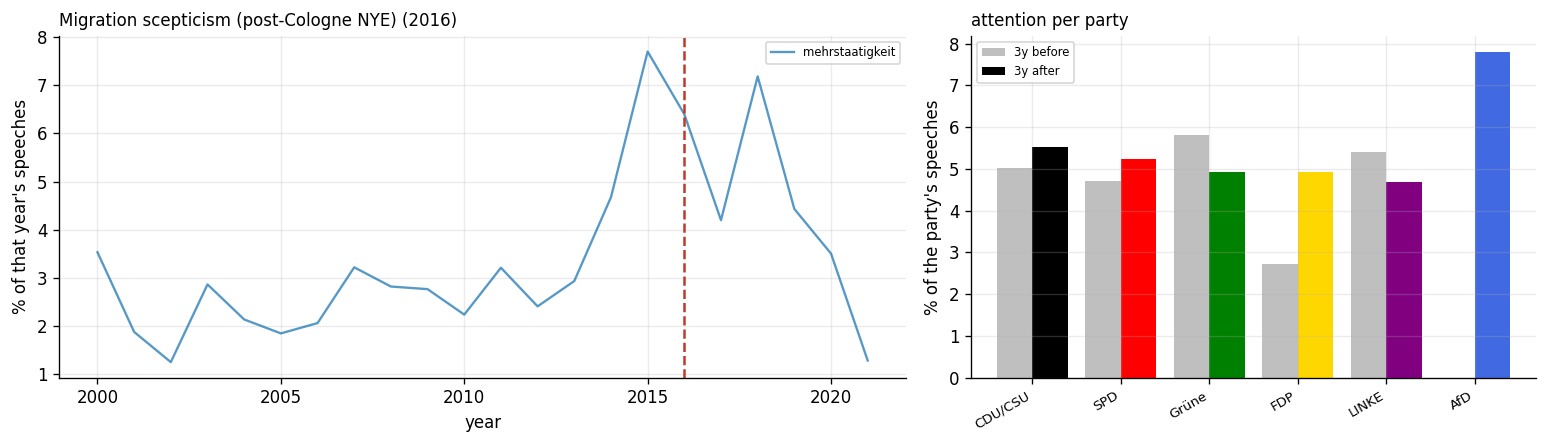

share of each party's speeches on these topics, % — Migration scepticism (post-Cologne NYE)
         mehrstaatigkeit
party                   
AfD                 6.03
CDU/CSU             3.43
FDP                 2.70
Grüne               4.04
LINKE               4.13
PDS                 2.10
SPD                 3.19 



In [58]:
WINDOW = 3      # years before / after the event used for the party comparison

def frequency_figure(ev):
    "Attention to an event's topics: over time, and per party before vs after."
    on_topic = df.topic_emb_full_name.isin(ev["topics"])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8),
                                   gridspec_kw={"width_ratios": [1.5, 1]})

    # --- left: share of the year's speeches, one line per topic plus the total
    for t in ev["topics"]:
        share = df.topic_emb_full_name.eq(t).groupby(df.year).mean()
        ax1.plot(share.index, 100 * share.values, lw=1.4, alpha=.75,
                 label=t.split("/")[0][:22])
    if len(ev["topics"]) > 1:
        tot = on_topic.groupby(df.year).mean()
        ax1.plot(tot.index, 100 * tot.values, lw=2.4, color="0.2", label="all topics together")
    ax1.axvline(ev["year"], color="#c0392b", ls="--", lw=1.5)
    ax1.set_xlabel("year"); ax1.set_ylabel("% of that year's speeches")
    ax1.set_title(f"{ev['label']} ({ev['year']})", loc="left", fontsize=10)
    ax1.legend(fontsize=7)

    # --- right: per party, share of its own speeches, before vs after
    pre  = df[df.year.between(ev["year"] - WINDOW, ev["year"] - 1)]
    post = df[df.year.between(ev["year"] + 1, ev["year"] + WINDOW)]
    parties = [p for p in PARTY_COLORS if p in set(pre.party) | set(post.party)]
    b = [100 * pre.loc[pre.party == p, "topic_emb_full_name"].isin(ev["topics"]).mean()
         for p in parties]
    a = [100 * post.loc[post.party == p, "topic_emb_full_name"].isin(ev["topics"]).mean()
         for p in parties]
    x = np.arange(len(parties))
    ax2.bar(x - 0.2, b, 0.4, color="0.75", label=f"{WINDOW}y before")
    ax2.bar(x + 0.2, a, 0.4, color=[PARTY_COLORS[p] for p in parties], label=f"{WINDOW}y after")
    ax2.set_xticks(x); ax2.set_xticklabels(parties, rotation=30, ha="right", fontsize=8)
    ax2.set_ylabel("% of the party's speeches")
    ax2.set_title("attention per party", loc="left", fontsize=10)
    ax2.legend(fontsize=7)

    plt.tight_layout()
    slug = "".join(ch if ch.isalnum() else "_" for ch in ev["label"].lower())[:28]
    plt.savefig(f"fig_freq_{ev['year']}_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- the same numbers as a table: party x topic, share of the party's speeches
    d = df[on_topic]
    tab = (100 * pd.crosstab(d.party, d.topic_emb_full_name).div(
           df.groupby("party").size(), axis=0)).round(2)
    tab.columns = [c.split("/")[0][:22] for c in tab.columns]
    print(f"share of each party's speeches on these topics, % — {ev['label']}")
    print(tab.to_string(), "\n")
    return tab


for ev in EVENTS:
    frequency_figure(ev)

*Interpretation.* Only some of the events actually reorganise the agenda.

**Lehman is the textbook case.** Attention runs at about 1% through the early 2000s, rises to 3.4% in
2008, peaks at 5.9% in 2009 and decays back to roughly 1.8% by 2014. Every party roughly triples in the
three years after against the three before: CDU/CSU 1.27 → 4.65%, FDP 1.16 → 4.22%, SPD 1.32 → 3.72%,
Grüne 1.25 → 3.58%, LINKE 0.82 → 3.47%. Nobody owns the crisis — that is what a pure agenda effect
looks like.

**9/11 is a mandate cycle, not a shock.** Attention goes from 0.06% in 2000 to 1.2% in 2001 and 1.8% in
2002, but the real peaks come much later — 3.5% in 2007 and 3.1% in 2008, the years of contested ISAF
renewals — and the series falls below 1% after 2014 as the deployment winds down. The before/after bars
should not be read here at all: the corpus starts in 2000, so the "3 years before" window is a single
year in which the topic barely existed, which is why those bars are almost empty. The whole-period table
is the more reliable read, and it is remarkably flat: every party between 1.27% and 1.45%, except the
AfD at 0.72%, which was not in parliament for any of the contested mandates. The mandate debate is
compulsory for all.

**Fukushima does not fit the crisis pattern.** The peak is 2010, the year *before* the disaster, at
5.2% — that is the Laufzeitverlängerung of autumn 2010. Fukushima arrived into a debate already running
at full volume (4.5% in 2011) and attention decays afterwards without returning to the 2010 level. The
party panel says the same: the Grüne fall from 6.15% to 4.47%, the CDU/CSU from 2.77% to 1.40%, the SPD
and LINKE also *down*; only the FDP rises slightly (1.77 → 2.35%). The table splits the topic
informatively — reactor safety is the Grüne's own subject (2.57% of their speeches against 0.43–0.64%
for CDU/CSU, FDP and SPD), while waste storage is spread evenly across all parties at 1.1–1.3%.

**Migration peaks a year before the event that dates it.** The series climbs to 7.7% in 2015, dips to
4.2% in 2017, reaches a second peak of 7.2% in 2018 and falls to 1.3% in the 2021 stub year — the summer
of 2015 and the 2018 asylum disputes are the real breaks, not the Cologne New Year's Eve. This is also
the only event with a clear owner: the AfD spends 6.03% of its speeches on the topic over the whole
period against 2.70–4.13% for everyone else, and 7.8% in its first three years in parliament. The
before/after bars are otherwise almost flat — CDU/CSU 5.0 → 5.5%, SPD 4.7 → 5.3%, FDP 2.7 → 5.0%, while
the Grüne (5.8 → 4.9%) and LINKE (5.4 → 4.7%) go slightly down.

One caveat on the tables: they are computed over the whole 2000–2021 period, so they describe a party's
general profile on the topic rather than its behaviour around the event. The bars in the right panel are
the ones restricted to the ±3-year windows.